# Acceleration-only CNN representation learning and retrieval evaluation

本 notebook 从 WritingRing 的 `segmentation_padded` producer 输出中读取所有 `user_*/action_*` package，严格按 **user** 划分 train / validation / test，使用 `paddedSpikeIMU[..., 15:18]` 的三轴加速度训练 1D CNN，并评估其 256-D penultimate representation。

实验协议：

- **输入**：三轴 acceleration，shape `(B, 3, T)`；仓库 schema 中对应 channels `15:18`，单位为 `m/s²`。
- **切分**：user-disjoint；同一 user 的全部 action、package 和 segment 必须进入同一个 split。
- **mask**：`valid_mask` 参与 train-only normalization、输入清零、逐层有效长度传播和 masked global average pooling。
- **模型选择**：仅根据 validation balanced accuracy 保存 best checkpoint。
- **正式 retrieval**：test query → train gallery；K 由 validation query → train gallery 选择。
- **正式 geometry diagnostics**：仅在 held-out test-user embeddings 上计算。

仓库依据：

- [`docs/notes/SPIKE_ENCODING.md`](../docs/notes/SPIKE_ENCODING.md)：21-channel SpikeIMU layout。
- [`docs/notes/SEGMENT_PADDING.md`](../docs/notes/SEGMENT_PADDING.md)：右侧 padding、`valid_lengths`、`valid_mask`、manifest/summary contract。
- [`snn/action0_dataset.py`](../snn/action0_dataset.py)：root metadata validation 和 padded package schema checks。
- [`snn/train_action0.py`](../snn/train_action0.py)：user split validation、random seed、device selection。
- [`scripts/reconstruct_padded_spike_accel.py`](../scripts/reconstruct_padded_spike_accel.py)：manifest 与 padded-package 一致性检查。

> 本 notebook 不依赖 scikit-learn；kNN、mAP、prototype、linear probe、KMeans、NMI、ARI 和 silhouette 均使用 NumPy / PyTorch 实现。


## 1. Imports and repository helpers

在仓库根目录或 `notebooks/` 目录启动 Jupyter。环境建议：

```bash
conda activate writingring-viz
python -m pip install -e ".[snn,notebook]"
```


In [1]:
from __future__ import annotations

import copy
import json
import math
import os
import random
import sys
from dataclasses import asdict, dataclass
from pathlib import Path
from typing import Any, Mapping, Sequence

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from IPython.display import display
from torch import nn
from torch.utils.data import DataLoader, Dataset, TensorDataset


def locate_repository_root() -> Path:
    """Locate the editable WritingRing repository without hard-coding an absolute path."""
    candidates = [Path.cwd(), *Path.cwd().parents]
    for candidate in candidates:
        if (candidate / "pyproject.toml").is_file() and (candidate / "snn").is_dir():
            return candidate.resolve()

    try:
        import snn as installed_snn
    except ModuleNotFoundError as error:
        raise RuntimeError(
            "Could not locate the WritingRing repository. Start Jupyter from the repository "
            "or install it with `python -m pip install -e \".[snn,notebook]\"`."
        ) from error
    return Path(installed_snn.__file__).resolve().parent.parent


REPOSITORY_ROOT = locate_repository_root()
if str(REPOSITORY_ROOT) not in sys.path:
    sys.path.insert(0, str(REPOSITORY_ROOT))

import snn  # noqa: E402
from snn.action0_dataset import (  # noqa: E402
    Action0DatasetError,
    PADDING_DATASET_SUMMARY_FILENAME,
    SPIKE_IMU_CHANNEL_COUNT,
    load_padding_dataset_metadata,
)
from snn.action0_engine import _classification_metrics  # noqa: E402
from snn.train_action0 import (  # noqa: E402
    _resolve_device,
    _set_random_seed,
    _validate_user_splits,
)
from writingring.segment_padding import SPIKE_IMU_FEATURE_SCHEMA  # noqa: E402

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 200)

print(f"Repository root: {REPOSITORY_ROOT}")
print(f"snn module:      {Path(snn.__file__).resolve()}")
print(f"PyTorch:         {torch.__version__}")


Repository root: /home/ted/project/writingring-viz
snn module:      /home/ted/project/writingring-viz/snn/__init__.py
PyTorch:         2.11.0+cu130


## 2. Experiment configuration

`ROOT` 可以是：

1. 直接指向包含 `padding_dataset_summary.json` 的 `segmentation_padded/`；
2. 指向其父级 combination root（其中有 `segmentation_padded/`）；
3. 指向更高层目录，但其下必须只找到一个 `padding_dataset_summary.json`。

默认自动按 user 随机切分。若需要固定名单，将三个 `EXPLICIT_*_USERS` 全部设为 list；不能只设置其中一部分。


In [2]:
# -----------------------------
# Data root and split
# -----------------------------
ROOT = Path("outputs/action0_rectified/low-pass/aligned-board-events")

EXPLICIT_TRAIN_USERS: list[str] | None = None
EXPLICIT_VAL_USERS: list[str] | None = None
EXPLICIT_TEST_USERS: list[str] | None = None

TRAIN_FRACTION = 0.70
VAL_FRACTION = 0.15
RANDOM_SEED = 12345
REQUIRE_ALL_USERS_ASSIGNED = True
REQUIRE_ALL_LABELS_IN_ALL_SPLITS = True

# -----------------------------
# DataLoader and normalization
# -----------------------------
BATCH_SIZE = 128
NUM_WORKERS = 0
NORMALIZATION_CHUNK_SEGMENTS = 256

# -----------------------------
# CNN training
# -----------------------------
NUM_EPOCHS = 30
LEARNING_RATE = 5e-4
WEIGHT_DECAY = 0.0
USE_CLASS_WEIGHTS = False  # labels are expected to be approximately balanced
EARLY_STOPPING_PATIENCE: int | None = 10
MAX_TRAIN_BATCHES: int | None = None  # e.g. 2 for a quick smoke run
GRAD_CLIP_NORM: float | None = None
USE_GPU = True

# -----------------------------
# Representation evaluation
# -----------------------------
K_VALUES = (1, 3, 5, 10, 20, 50)
KNN_K_CANDIDATES = (1, 3, 5, 7, 10, 15, 20)
SIMILARITY_QUERY_BATCH_SIZE = 128

LINEAR_PROBE_EPOCHS = 200
LINEAR_PROBE_LEARNING_RATE = 1e-2
LINEAR_PROBE_WEIGHT_DECAY = 1e-4
LINEAR_PROBE_BATCH_SIZE = 512
LINEAR_PROBE_PATIENCE = 30

KMEANS_N_INIT = 10
KMEANS_MAX_ITER = 100
SILHOUETTE_MAX_SAMPLES = 3000
PCA_MAX_SAMPLES = 5000

# -----------------------------
# Outputs
# -----------------------------
OUTPUT_DIR = REPOSITORY_ROOT / "notebooks" / "artifacts" / "acceleration_cnn_representation"
SAVE_ARTIFACTS = True
SAVE_FIGURES = True

ACCELERATION_SLICE = slice(15, 18)
ACCELERATION_CHANNEL_NAMES = ("acceleration_x_m_s2", "acceleration_y_m_s2", "acceleration_z_m_s2")

if TRAIN_FRACTION <= 0 or VAL_FRACTION <= 0 or TRAIN_FRACTION + VAL_FRACTION >= 1:
    raise ValueError("TRAIN_FRACTION and VAL_FRACTION must be positive and sum to less than 1")
if BATCH_SIZE <= 0 or NUM_EPOCHS <= 0 or LEARNING_RATE <= 0:
    raise ValueError("BATCH_SIZE, NUM_EPOCHS, and LEARNING_RATE must be positive")
if any(k <= 0 for k in (*K_VALUES, *KNN_K_CANDIDATES)):
    raise ValueError("All K values must be positive")

print(f"Configured ROOT: {ROOT}")
print(f"Output directory: {OUTPUT_DIR}")


Configured ROOT: outputs/action0_rectified/low-pass/aligned-board-events
Output directory: /home/ted/project/writingring-viz/notebooks/artifacts/acceleration_cnn_representation


## 3. Resolve and validate padded packages

这里复用仓库的 `load_padding_dataset_metadata()` 检查 root-level contract，并按照 producer/reconstruction 代码中的规则验证每个 package：

- `paddedSpikeIMU`: `(S, T, 21)`，有限数值；
- `labels`: `(S,)`；
- `valid_lengths`: `(S,)`，范围 `[1, T]`；
- `valid_mask`: `(S, T)`，bool 且严格等于连续前缀 `arange(T) < valid_length`；
- `padding_summary`: `target_length` 一致、`padding_side=right`、`overflow_policy=skip`；
- `padding_manifest`: exported rows 与 padded axis 0 一一对应，`output_segment_index` 连续。

输入文件使用 memory mapping，避免一次性把整棵 dataset 复制进 RAM。


In [3]:
def natural_key(text: str) -> tuple[object, ...]:
    parts: list[object] = []
    token = ""
    numeric = False
    for char in str(text):
        current_numeric = char.isdigit()
        if token and current_numeric != numeric:
            parts.append(int(token) if numeric else token.lower())
            token = ""
        token += char
        numeric = current_numeric
    if token:
        parts.append(int(token) if numeric else token.lower())
    return tuple(parts)


def load_json_object(path: Path) -> dict[str, object]:
    try:
        value = json.loads(path.read_text(encoding="utf-8"))
    except (OSError, UnicodeError, json.JSONDecodeError) as error:
        raise Action0DatasetError(f"Could not read JSON object {path}: {error}") from error
    if not isinstance(value, dict):
        raise Action0DatasetError(f"Expected JSON object: {path}")
    return value


def parse_bool_value(value: object, *, context: str) -> bool:
    if isinstance(value, (bool, np.bool_)):
        return bool(value)
    text = str(value).strip().lower()
    if text in {"true", "1", "yes"}:
        return True
    if text in {"false", "0", "no"}:
        return False
    raise Action0DatasetError(f"{context}: expected boolean, got {value!r}")


def parse_manifest_int(value: object, *, field: str, path: Path) -> int:
    text = str(value).strip()
    if not text or text.lower() in {"nan", "none", "null"}:
        raise Action0DatasetError(f"{path}: required integer field {field!r} is empty")
    try:
        return int(text, 10)
    except ValueError:
        pass
    try:
        number = float(text)
    except ValueError as error:
        raise Action0DatasetError(
            f"{path}: field {field!r} must be integer-valued, got {value!r}"
        ) from error
    if not math.isfinite(number) or not number.is_integer():
        raise Action0DatasetError(
            f"{path}: field {field!r} must be integer-valued, got {value!r}"
        )
    return int(number)


def resolve_padded_root(root: Path) -> Path:
    root = Path(root).expanduser()
    if not root.is_absolute():
        root = REPOSITORY_ROOT / root
    root = root.resolve()

    direct_summary = root / PADDING_DATASET_SUMMARY_FILENAME
    if direct_summary.is_file():
        return root

    child = root / "segmentation_padded"
    if (child / PADDING_DATASET_SUMMARY_FILENAME).is_file():
        return child

    candidates = sorted(root.rglob(PADDING_DATASET_SUMMARY_FILENAME)) if root.is_dir() else []
    if len(candidates) == 1:
        return candidates[0].parent
    if not candidates:
        raise FileNotFoundError(
            f"Could not find {PADDING_DATASET_SUMMARY_FILENAME!r} below {root}. "
            "Point ROOT to a completed segmentation_padded dataset."
        )
    candidate_text = "\n".join(f"  - {path.parent}" for path in candidates)
    raise Action0DatasetError(
        "ROOT resolves to multiple padded datasets; select one exact segmentation_padded root:\n"
        + candidate_text
    )


@dataclass(slots=True)
class PaddedPackage:
    user: str
    action: str
    stem: str
    directory: Path
    padded_spike_imu_path: Path
    labels_path: Path
    valid_lengths_path: Path
    valid_mask_path: Path
    padding_manifest_path: Path
    padding_summary_path: Path
    padded_spike_imu: np.ndarray
    labels: np.ndarray
    valid_lengths: np.ndarray
    valid_mask: np.ndarray

    @property
    def segment_count(self) -> int:
        return int(self.padded_spike_imu.shape[0])

    @property
    def padded_length(self) -> int:
        return int(self.padded_spike_imu.shape[1])


def discover_padded_spike_paths(padded_root: Path) -> tuple[Path, ...]:
    paths = sorted(
        padded_root.rglob("*_paddedSpikeIMU.npy"),
        key=lambda path: tuple(natural_key(part) for part in path.relative_to(padded_root).parts),
    )
    if not paths:
        raise Action0DatasetError(f"No *_paddedSpikeIMU.npy files found below {padded_root}")
    return tuple(paths)


def assert_finite_memmap(values: np.ndarray, *, path: Path, chunk_segments: int = 256) -> None:
    if not np.issubdtype(values.dtype, np.number):
        raise Action0DatasetError(f"Expected numeric array: {path}; dtype={values.dtype}")
    for start in range(0, len(values), chunk_segments):
        stop = min(start + chunk_segments, len(values))
        if not np.isfinite(values[start:stop]).all():
            raise Action0DatasetError(f"Non-finite values found in {path}, segments {start}:{stop}")


def load_and_validate_padded_package(
    padded_path: Path,
    *,
    padded_root: Path,
    root_target_length: int,
) -> tuple[PaddedPackage, pd.DataFrame]:
    action_dir = padded_path.parent
    user_dir = action_dir.parent
    if not user_dir.name.startswith("user_") or not action_dir.name.startswith("action_"):
        raise Action0DatasetError(
            f"Expected <root>/user_*/action_* package hierarchy, got {padded_path}"
        )

    user = user_dir.name
    action = action_dir.name.removeprefix("action_")
    stem = padded_path.name.removesuffix("_paddedSpikeIMU.npy")
    expected_stem = f"{user}_action_{action}"
    if stem != expected_stem:
        raise Action0DatasetError(
            f"Package stem mismatch in {action_dir}: expected {expected_stem!r}, got {stem!r}"
        )

    labels_path = action_dir / f"{stem}_labels.npy"
    valid_lengths_path = action_dir / f"{stem}_valid_lengths.npy"
    valid_mask_path = action_dir / f"{stem}_valid_mask.npy"
    padding_manifest_path = action_dir / f"{stem}_padding_manifest.csv"
    padding_summary_path = action_dir / f"{stem}_padding_summary.json"
    required = (
        labels_path,
        valid_lengths_path,
        valid_mask_path,
        padding_manifest_path,
        padding_summary_path,
    )
    missing = [str(path) for path in required if not path.is_file()]
    if missing:
        raise FileNotFoundError(
            f"Missing required padded package siblings for {user}/action_{action}: "
            + ", ".join(missing)
        )

    padded_spike = np.load(padded_path, allow_pickle=False, mmap_mode="r")
    labels = np.load(labels_path, allow_pickle=False).astype(str)
    valid_lengths_raw = np.load(valid_lengths_path, allow_pickle=False)
    if not np.issubdtype(valid_lengths_raw.dtype, np.integer):
        raise Action0DatasetError(
            f"{valid_lengths_path}: valid_lengths must have integer dtype, "
            f"got {valid_lengths_raw.dtype}"
        )
    valid_lengths = valid_lengths_raw.astype(np.int64, copy=False)
    valid_mask = np.load(valid_mask_path, allow_pickle=False, mmap_mode="r")

    if padded_spike.ndim != 3 or padded_spike.shape[2] != SPIKE_IMU_CHANNEL_COUNT:
        raise Action0DatasetError(
            f"{padded_path}: expected (S, T, {SPIKE_IMU_CHANNEL_COUNT}), got {padded_spike.shape}"
        )
    segment_count, padded_length, channel_count = map(int, padded_spike.shape)
    if segment_count <= 0 or padded_length <= 0:
        raise Action0DatasetError(f"{padded_path}: padded array must be nonempty")
    if padded_length != int(root_target_length):
        raise Action0DatasetError(
            f"{padded_path}: T={padded_length} != root target_length={root_target_length}"
        )
    if channel_count != 21:
        raise Action0DatasetError(f"{padded_path}: expected 21 channels")
    assert_finite_memmap(padded_spike, path=padded_path)

    if labels.shape != (segment_count,):
        raise Action0DatasetError(
            f"{labels_path}: expected shape {(segment_count,)}, got {labels.shape}"
        )
    if valid_lengths.shape != (segment_count,):
        raise Action0DatasetError(
            f"{valid_lengths_path}: expected shape {(segment_count,)}, got {valid_lengths.shape}"
        )
    if valid_mask.shape != (segment_count, padded_length):
        raise Action0DatasetError(
            f"{valid_mask_path}: expected shape {(segment_count, padded_length)}, got {valid_mask.shape}"
        )
    if valid_mask.dtype != np.dtype(np.bool_):
        raise Action0DatasetError(f"{valid_mask_path}: valid_mask must have bool dtype")
    if np.any(valid_lengths <= 0) or np.any(valid_lengths > padded_length):
        raise Action0DatasetError(
            f"{valid_lengths_path}: valid lengths must lie in [1, {padded_length}]"
        )

    time_index = np.arange(padded_length, dtype=np.int64)[None, :]
    for start in range(0, segment_count, 1024):
        stop = min(start + 1024, segment_count)
        expected_mask = time_index < valid_lengths[start:stop, None]
        if not np.array_equal(valid_mask[start:stop], expected_mask):
            raise Action0DatasetError(
                f"{valid_mask_path}: mask must be a contiguous right-padded prefix matching valid_lengths"
            )

    padding_summary = load_json_object(padding_summary_path)
    summary_target = padding_summary.get("target_length")
    if not isinstance(summary_target, int) or isinstance(summary_target, bool):
        raise Action0DatasetError(f"{padding_summary_path}: target_length must be an integer")
    if summary_target != padded_length:
        raise Action0DatasetError(
            f"{padding_summary_path}: target_length={summary_target} != padded T={padded_length}"
        )
    if padding_summary.get("padding_side") != "right":
        raise Action0DatasetError(f"{padding_summary_path}: expected padding_side='right'")
    if padding_summary.get("overflow_policy") != "skip":
        raise Action0DatasetError(f"{padding_summary_path}: expected overflow_policy='skip'")
    if padding_summary.get("input_kind") not in (None, "spike-imu"):
        raise Action0DatasetError(f"{padding_summary_path}: expected SpikeIMU padding package")
    if padding_summary.get("feature_schema") not in (None, SPIKE_IMU_FEATURE_SCHEMA):
        raise Action0DatasetError(f"{padding_summary_path}: unexpected feature_schema")

    manifest = pd.read_csv(padding_manifest_path, dtype=str, keep_default_na=False)
    required_columns = {
        "segment_index",
        "output_segment_index",
        "exported",
        "original_length",
        "target_length",
    }
    missing_columns = required_columns.difference(manifest.columns)
    if missing_columns:
        raise Action0DatasetError(
            f"{padding_manifest_path}: missing columns {sorted(missing_columns)}"
        )
    if manifest.empty:
        raise Action0DatasetError(f"{padding_manifest_path}: manifest has no rows")

    exported_mask = manifest["exported"].map(
        lambda value: parse_bool_value(value, context=str(padding_manifest_path))
    )
    exported = manifest.loc[exported_mask].copy()
    if len(exported) != segment_count:
        raise Action0DatasetError(
            f"{padding_manifest_path}: exported rows={len(exported)} != padded segments={segment_count}"
        )

    for field in ("segment_index", "output_segment_index", "original_length", "target_length"):
        exported[f"_{field}"] = [
            parse_manifest_int(value, field=field, path=padding_manifest_path)
            for value in exported[field]
        ]
    exported = exported.sort_values("_output_segment_index", kind="stable").reset_index(drop=True)
    if exported["_output_segment_index"].tolist() != list(range(segment_count)):
        raise Action0DatasetError(
            f"{padding_manifest_path}: output_segment_index must be contiguous 0..S-1"
        )
    if not np.array_equal(exported["_original_length"].to_numpy(np.int64), valid_lengths):
        raise Action0DatasetError(
            f"{padding_manifest_path}: original_length does not match valid_lengths"
        )
    if set(exported["_target_length"].tolist()) != {padded_length}:
        raise Action0DatasetError(
            f"{padding_manifest_path}: exported target_length is inconsistent"
        )
    if "label" in exported.columns:
        manifest_labels = exported["label"].astype(str).to_numpy()
        if not np.array_equal(manifest_labels, labels):
            raise Action0DatasetError(
                f"{padding_manifest_path}: exported labels do not match padded labels"
            )

    provenance_rows: list[dict[str, object]] = []
    for output_index, row in exported.iterrows():
        provenance_rows.append(
            {
                "sample_id": f"{user}/action_{action}/{stem}/segment_{output_index:06d}",
                "user": user,
                "action": action,
                "stem": stem,
                "segment_index": int(output_index),
                "source_segment_index": int(row["_segment_index"]),
                "dataset_id": row.get("dataset_id", ""),
                "label": str(labels[output_index]),
                "valid_length": int(valid_lengths[output_index]),
                "package_relative_dir": str(action_dir.relative_to(padded_root)),
            }
        )

    package = PaddedPackage(
        user=user,
        action=action,
        stem=stem,
        directory=action_dir,
        padded_spike_imu_path=padded_path,
        labels_path=labels_path,
        valid_lengths_path=valid_lengths_path,
        valid_mask_path=valid_mask_path,
        padding_manifest_path=padding_manifest_path,
        padding_summary_path=padding_summary_path,
        padded_spike_imu=padded_spike,
        labels=labels,
        valid_lengths=valid_lengths,
        valid_mask=valid_mask,
    )
    return package, pd.DataFrame(provenance_rows)


def load_all_padded_packages(
    padded_root: Path,
    *,
    root_target_length: int,
) -> tuple[tuple[PaddedPackage, ...], pd.DataFrame]:
    packages: list[PaddedPackage] = []
    manifest_parts: list[pd.DataFrame] = []
    seen_identity: set[tuple[str, str]] = set()

    for padded_path in discover_padded_spike_paths(padded_root):
        package, rows = load_and_validate_padded_package(
            padded_path,
            padded_root=padded_root,
            root_target_length=root_target_length,
        )
        identity = (package.user, package.action)
        if identity in seen_identity:
            raise Action0DatasetError(f"Duplicate package identity: {identity}")
        seen_identity.add(identity)
        package_index = len(packages)
        rows["package_index"] = package_index
        packages.append(package)
        manifest_parts.append(rows)

    sample_manifest = pd.concat(manifest_parts, ignore_index=True)
    if sample_manifest["sample_id"].duplicated().any():
        duplicates = sample_manifest.loc[
            sample_manifest["sample_id"].duplicated(keep=False), "sample_id"
        ].tolist()
        raise Action0DatasetError(f"Duplicate sample IDs: {duplicates[:10]}")
    return tuple(packages), sample_manifest


In [4]:
PADDED_ROOT = resolve_padded_root(ROOT)
producer_metadata = load_padding_dataset_metadata(PADDED_ROOT)

if producer_metadata.input_kind != "spike-imu":
    raise Action0DatasetError(f"Expected input_kind='spike-imu', got {producer_metadata.input_kind!r}")
if producer_metadata.feature_schema != SPIKE_IMU_FEATURE_SCHEMA:
    raise Action0DatasetError(
        f"Expected feature_schema={SPIKE_IMU_FEATURE_SCHEMA!r}, "
        f"got {producer_metadata.feature_schema!r}"
    )
if producer_metadata.channel_count != SPIKE_IMU_CHANNEL_COUNT:
    raise Action0DatasetError(
        f"Expected {SPIKE_IMU_CHANNEL_COUNT} channels, got {producer_metadata.channel_count}"
    )
if producer_metadata.padding_side != "right":
    raise Action0DatasetError("This notebook requires canonical right padding")

packages, sample_manifest = load_all_padded_packages(
    PADDED_ROOT,
    root_target_length=producer_metadata.target_length,
)

print(f"Padded root:       {PADDED_ROOT}")
print(f"Packages:          {len(packages)}")
print(f"Users:             {sample_manifest['user'].nunique()}")
print(f"Actions:           {sample_manifest['action'].nunique()}")
print(f"Segments:          {len(sample_manifest)}")
print(f"Target length:     {producer_metadata.target_length}")
print(f"Sampling rate:     {producer_metadata.sampling_rate_hz:g} Hz")
print(f"Feature schema:    {producer_metadata.feature_schema}")
print(f"Acceleration slice:{ACCELERATION_SLICE.start}:{ACCELERATION_SLICE.stop}")

display(sample_manifest.head())


Padded root:       /home/ted/project/writingring-viz/outputs/action0_rectified/low-pass/aligned-board-events/segmentation_padded
Packages:          21
Users:             21
Actions:           1
Segments:          1924
Target length:     600
Sampling rate:     200 Hz
Feature schema:    signed_wavelet_events_plus_imu_v1
Acceleration slice:15:18


,sample_id,user,action,stem,segment_index,source_segment_index,dataset_id,label,valid_length,package_relative_dir,package_index
0,user_0/action_0/user_0_action_0/segment_000000,user_0,0,user_0_action_0,0,0,0,f,275,user_0/action_0,0
1,user_0/action_0/user_0_action_0/segment_000001,user_0,0,user_0_action_0,1,1,0,j,224,user_0/action_0,0
2,user_0/action_0/user_0_action_0/segment_000002,user_0,0,user_0_action_0,2,2,0,b,288,user_0/action_0,0
3,user_0/action_0/user_0_action_0/segment_000003,user_0,0,user_0_action_0,3,3,0,x,257,user_0/action_0,0
4,user_0/action_0/user_0_action_0/segment_000004,user_0,0,user_0_action_0,4,4,0,e,262,user_0/action_0,0


## 4. Dataset overview

先检查 user/action/label/segment length。这里不做 sample-level balancing；label 统计只用于验证 user split 后的覆盖与近似均衡程度。


User summary


,segments,actions,labels,mean_valid_length,min_valid_length,max_valid_length
user,,,,,,
user_0,94,1,52,317.074468,147,456
user_1,135,1,52,248.555556,125,390
user_2,94,1,51,262.691489,166,414
user_3,119,1,51,288.445378,169,431
user_4,72,1,48,294.763889,184,431
user_5,95,1,52,246.884211,147,353
user_6,129,1,52,231.899225,135,412
user_7,118,1,52,367.940678,152,582
user_8,93,1,52,278.924731,154,600


Label summary


,segments,users
label,,
A,37,21
B,36,20
C,42,21
D,41,21
E,40,20
F,40,20
G,40,21
H,42,21
I,38,19


Action summary


,segments,users,labels
action,,,
0,1924,21,52


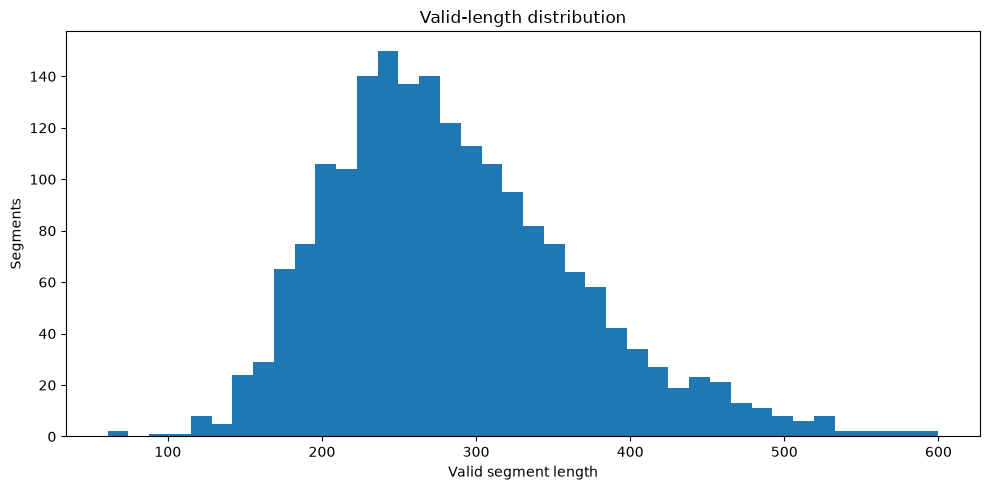

In [5]:
user_summary = (
    sample_manifest.groupby("user", sort=False)
    .agg(
        segments=("sample_id", "size"),
        actions=("action", "nunique"),
        labels=("label", "nunique"),
        mean_valid_length=("valid_length", "mean"),
        min_valid_length=("valid_length", "min"),
        max_valid_length=("valid_length", "max"),
    )
    .sort_index(key=lambda index: index.map(natural_key))
)
label_summary = (
    sample_manifest.groupby("label", sort=True)
    .agg(segments=("sample_id", "size"), users=("user", "nunique"))
    .sort_index()
)
action_summary = (
    sample_manifest.groupby("action", sort=False)
    .agg(segments=("sample_id", "size"), users=("user", "nunique"), labels=("label", "nunique"))
    .sort_index(key=lambda index: index.map(natural_key))
)

print("User summary")
display(user_summary)
print("Label summary")
display(label_summary)
print("Action summary")
display(action_summary)

plt.figure(figsize=(10, 5))
plt.hist(sample_manifest["valid_length"].to_numpy(), bins=40)
plt.xlabel("Valid segment length")
plt.ylabel("Segments")
plt.title("Valid-length distribution")
plt.tight_layout()
if SAVE_FIGURES:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    plt.savefig(OUTPUT_DIR / "valid_length_distribution.png", dpi=180)
plt.show()


## 5. User-disjoint train / validation / test split

自动切分逻辑只在 user 层工作。每个 user 的所有 rows 继承同一个 split。若显式名单被提供，默认要求 root 中的所有 user 都被分配。


In [6]:
def normalize_user_name(value: object) -> str:
    text = str(value)
    if text.startswith("user_"):
        return text
    if text.isdecimal():
        return f"user_{text}"
    return text


def normalize_user_list(values: Sequence[object]) -> list[str]:
    normalized = [normalize_user_name(value) for value in values]
    if len(normalized) != len(set(normalized)):
        raise ValueError(f"User list contains duplicates: {normalized}")
    return normalized


def automatic_user_split(
    users: Sequence[str],
    *,
    train_fraction: float,
    val_fraction: float,
    seed: int,
) -> tuple[list[str], list[str], list[str]]:
    ordered = sorted(set(users), key=natural_key)
    if len(ordered) < 3:
        raise ValueError("At least three users are required for nonempty train/val/test splits")

    rng = np.random.default_rng(seed)
    shuffled = [ordered[index] for index in rng.permutation(len(ordered))]
    n_users = len(shuffled)
    n_train = max(1, min(n_users - 2, int(round(n_users * train_fraction))))
    n_val = max(1, min(n_users - n_train - 1, int(round(n_users * val_fraction))))
    n_test = n_users - n_train - n_val
    if n_test < 1:
        n_val -= 1
        n_test += 1
    if min(n_train, n_val, n_test) < 1:
        raise AssertionError("Internal split-size calculation produced an empty split")

    train = sorted(shuffled[:n_train], key=natural_key)
    val = sorted(shuffled[n_train : n_train + n_val], key=natural_key)
    test = sorted(shuffled[n_train + n_val :], key=natural_key)
    return train, val, test


explicit_values = (EXPLICIT_TRAIN_USERS, EXPLICIT_VAL_USERS, EXPLICIT_TEST_USERS)
if all(value is None for value in explicit_values):
    TRAIN_USERS, VAL_USERS, TEST_USERS = automatic_user_split(
        sample_manifest["user"].unique().tolist(),
        train_fraction=TRAIN_FRACTION,
        val_fraction=VAL_FRACTION,
        seed=RANDOM_SEED,
    )
elif all(value is not None for value in explicit_values):
    TRAIN_USERS = normalize_user_list(EXPLICIT_TRAIN_USERS or [])
    VAL_USERS = normalize_user_list(EXPLICIT_VAL_USERS or [])
    TEST_USERS = normalize_user_list(EXPLICIT_TEST_USERS or [])
else:
    raise ValueError(
        "Set all three EXPLICIT_TRAIN_USERS / EXPLICIT_VAL_USERS / EXPLICIT_TEST_USERS, "
        "or leave all three as None."
    )

_validate_user_splits(TRAIN_USERS, VAL_USERS, TEST_USERS)

available_users = set(sample_manifest["user"].unique())
assigned_users = set(TRAIN_USERS) | set(VAL_USERS) | set(TEST_USERS)
missing_users = sorted(assigned_users - available_users, key=natural_key)
unused_users = sorted(available_users - assigned_users, key=natural_key)
if missing_users:
    raise FileNotFoundError(f"Requested users are absent from PADDED_ROOT: {missing_users}")
if REQUIRE_ALL_USERS_ASSIGNED and unused_users:
    raise ValueError(f"Users were not assigned to a split: {unused_users}")

split_by_user = {
    **{user: "train" for user in TRAIN_USERS},
    **{user: "val" for user in VAL_USERS},
    **{user: "test" for user in TEST_USERS},
}
sample_manifest["split"] = sample_manifest["user"].map(split_by_user)
if sample_manifest["split"].isna().any():
    raise AssertionError("Every sample must inherit a split from its user")

for left_name, right_name in (("train", "val"), ("train", "test"), ("val", "test")):
    left_ids = set(sample_manifest.loc[sample_manifest["split"] == left_name, "sample_id"])
    right_ids = set(sample_manifest.loc[sample_manifest["split"] == right_name, "sample_id"])
    if left_ids & right_ids:
        raise AssertionError(f"Sample leakage between {left_name} and {right_name}")

all_labels = sorted(sample_manifest["label"].astype(str).unique().tolist())
class_to_idx = {label: index for index, label in enumerate(all_labels)}
idx_to_class = {index: label for label, index in class_to_idx.items()}
sample_manifest["label_idx"] = sample_manifest["label"].map(class_to_idx).astype(np.int64)

split_summary = (
    sample_manifest.groupby("split")
    .agg(users=("user", "nunique"), samples=("sample_id", "size"), labels=("label", "nunique"))
    .reindex(["train", "val", "test"])
)
label_split_counts = pd.crosstab(sample_manifest["label"], sample_manifest["split"]).reindex(
    index=all_labels,
    columns=["train", "val", "test"],
    fill_value=0,
)

if REQUIRE_ALL_LABELS_IN_ALL_SPLITS and (label_split_counts == 0).any().any():
    missing = label_split_counts[label_split_counts.eq(0).any(axis=1)]
    display(missing)
    raise ValueError(
        "At least one label is absent from a split. Change the user split or set "
        "REQUIRE_ALL_LABELS_IN_ALL_SPLITS=False only for an explicitly open-set experiment."
    )

print(f"Train users ({len(TRAIN_USERS)}): {TRAIN_USERS}")
print(f"Val users   ({len(VAL_USERS)}): {VAL_USERS}")
print(f"Test users  ({len(TEST_USERS)}): {TEST_USERS}")
display(split_summary)
display(label_split_counts)


Train users (15): ['user_0', 'user_1', 'user_3', 'user_4', 'user_5', 'user_6', 'user_7', 'user_9', 'user_10', 'user_11', 'user_12', 'user_15', 'user_17', 'user_18', 'user_19']
Val users   (3): ['user_8', 'user_14', 'user_20']
Test users  (3): ['user_2', 'user_13', 'user_16']


,users,samples,labels
split,,,
train,15,1372,52
val,3,276,52
test,3,276,52


split,train,val,test
label,,,
A,26,5,6
B,26,5,5
C,30,6,6
D,29,6,6
E,28,6,6
F,28,6,6
G,28,6,6
H,31,6,5
I,27,5,6


Per-label split fractions


split,train,val,test
label,,,
A,0.018950,0.018116,0.021739
B,0.018950,0.018116,0.018116
C,0.021866,0.021739,0.021739
D,0.021137,0.021739,0.021739
E,0.020408,0.021739,0.021739
F,0.020408,0.021739,0.021739
G,0.020408,0.021739,0.021739
H,0.022595,0.021739,0.018116
I,0.019679,0.018116,0.021739


Maximum absolute per-label deviation from its three-split mean: 0.007032


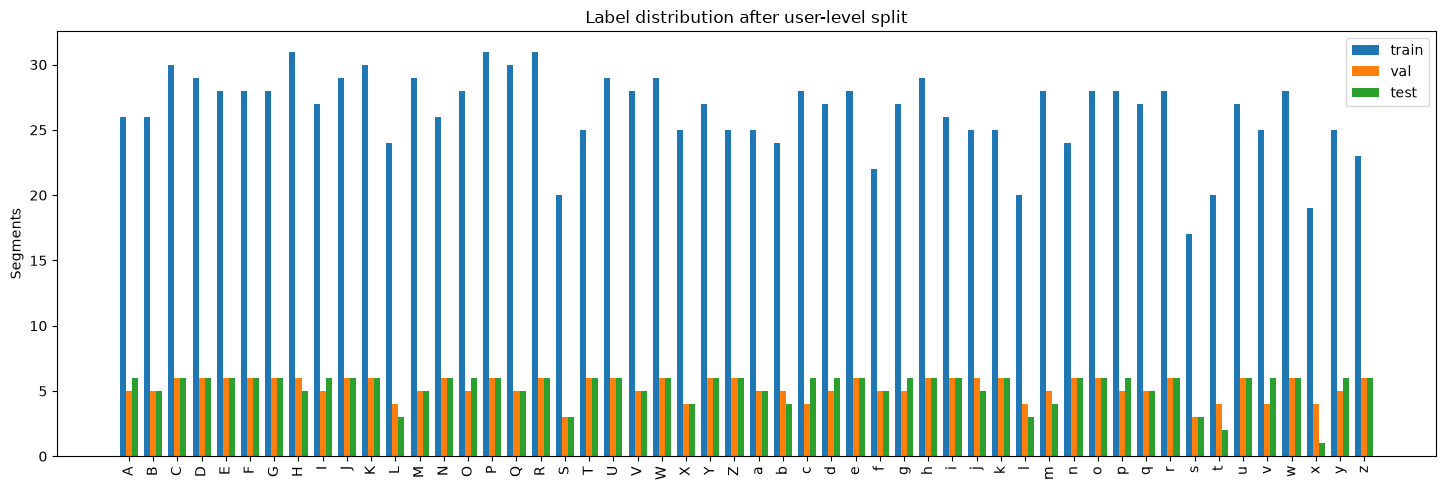

In [7]:
# Distribution diagnostics only; no segment is moved across user boundaries.
label_split_fraction = label_split_counts.div(label_split_counts.sum(axis=0), axis=1)
label_distribution_deviation = label_split_fraction.sub(
    label_split_fraction.mean(axis=1), axis=0
).abs()

print("Per-label split fractions")
display(label_split_fraction)
print(
    "Maximum absolute per-label deviation from its three-split mean: "
    f"{float(label_distribution_deviation.to_numpy().max()):.6f}"
)

plot_counts = label_split_counts.reset_index().melt(
    id_vars="label", var_name="split", value_name="segments"
)
plt.figure(figsize=(max(10, len(all_labels) * 0.28), 5))
for split_name in ("train", "val", "test"):
    values = plot_counts.loc[plot_counts["split"] == split_name, "segments"].to_numpy()
    x = np.arange(len(all_labels))
    offset = {"train": -0.25, "val": 0.0, "test": 0.25}[split_name]
    plt.bar(x + offset, values, width=0.25, label=split_name)
plt.xticks(np.arange(len(all_labels)), all_labels, rotation=90)
plt.ylabel("Segments")
plt.title("Label distribution after user-level split")
plt.legend()
plt.tight_layout()
if SAVE_FIGURES:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    plt.savefig(OUTPUT_DIR / "label_distribution_by_split.png", dpi=180)
plt.show()


## 6. Train-only, valid-mask-only acceleration normalization

统计量只来自 train users 且只累计 `valid_mask=True` 的时间点：

\[
\mu_d = \frac{\sum M_{it}X_{itd}}{\sum M_{it}},\qquad
\sigma_d = \sqrt{\frac{\sum M_{it}X_{itd}^2}{\sum M_{it}}-\mu_d^2}.
\]

每个 sample 标准化后再次把 invalid region 置零，因此 padding 不会变成 `(0-μ)/σ`。


In [8]:
def compute_masked_acceleration_stats(
    packages: Sequence[PaddedPackage],
    *,
    train_users: set[str],
    chunk_segments: int,
) -> tuple[np.ndarray, np.ndarray, int]:
    total = np.zeros(3, dtype=np.float64)
    total_sq = np.zeros(3, dtype=np.float64)
    valid_time_points = 0

    for package in packages:
        if package.user not in train_users:
            continue
        for start in range(0, package.segment_count, chunk_segments):
            stop = min(start + chunk_segments, package.segment_count)
            acceleration = np.asarray(
                package.padded_spike_imu[start:stop, :, ACCELERATION_SLICE],
                dtype=np.float64,
            )
            mask = np.asarray(package.valid_mask[start:stop], dtype=np.bool_)
            valid_values = acceleration[mask]
            if valid_values.ndim != 2 or valid_values.shape[1] != 3:
                raise AssertionError("Masked acceleration must have shape (valid_time_points, 3)")
            total += valid_values.sum(axis=0)
            total_sq += np.square(valid_values).sum(axis=0)
            valid_time_points += int(valid_values.shape[0])

    if valid_time_points <= 0:
        raise ValueError("Train split contains no valid acceleration samples")
    mean = total / valid_time_points
    variance = total_sq / valid_time_points - np.square(mean)
    variance = np.maximum(variance, 1e-12)
    std = np.sqrt(variance)
    if not np.isfinite(mean).all() or not np.isfinite(std).all() or np.any(std <= 0):
        raise FloatingPointError(f"Invalid normalization statistics: mean={mean}, std={std}")
    return mean, std, valid_time_points


acceleration_mean, acceleration_std, normalization_valid_time_points = (
    compute_masked_acceleration_stats(
        packages,
        train_users=set(TRAIN_USERS),
        chunk_segments=NORMALIZATION_CHUNK_SEGMENTS,
    )
)

normalization_table = pd.DataFrame(
    {
        "channel": ACCELERATION_CHANNEL_NAMES,
        "mean_m_s2": acceleration_mean,
        "std_m_s2": acceleration_std,
    }
)
print(f"Valid train time points used: {normalization_valid_time_points:,}")
display(normalization_table)


Valid train time points used: 398,318


,channel,mean_m_s2,std_m_s2
0,acceleration_x_m_s2,-0.738565,1.972249
1,acceleration_y_m_s2,0.184255,1.699627
2,acceleration_z_m_s2,0.228317,1.656201


## 7. Acceleration dataset and DataLoaders

每个 item 返回：

- `x`: `(3, T)`, `float32`；
- `label`: scalar `long`；
- `valid_mask`: `(T,)`, `bool`；
- `valid_length`: scalar `long`；
- `sample_id`: stable provenance key。


In [10]:
class AccelerationSegmentDataset(Dataset[dict[str, object]]):
    def __init__(
        self,
        packages: Sequence[PaddedPackage],
        sample_manifest: pd.DataFrame,
        *,
        split: str,
        mean: np.ndarray,
        std: np.ndarray,
    ) -> None:
        rows = sample_manifest.loc[sample_manifest["split"] == split].copy().reset_index(drop=True)
        if rows.empty:
            raise ValueError(f"Split {split!r} contains no samples")
        self.packages = tuple(packages)
        self.split = split
        self.package_indices = rows["package_index"].to_numpy(np.int64)
        self.segment_indices = rows["segment_index"].to_numpy(np.int64)
        self.labels = rows["label_idx"].to_numpy(np.int64)
        self.valid_lengths = rows["valid_length"].to_numpy(np.int64)
        self.sample_ids = rows["sample_id"].astype(str).tolist()
        self.users = rows["user"].astype(str).tolist()
        self.actions = rows["action"].astype(str).tolist()
        self.mean = np.asarray(mean, dtype=np.float32).reshape(1, 3)
        self.std = np.asarray(std, dtype=np.float32).reshape(1, 3)
        self.padded_length = int(self.packages[int(self.package_indices[0])].padded_length)

        if np.any(self.std <= 0) or not np.isfinite(self.mean).all() or not np.isfinite(self.std).all():
            raise ValueError("Normalization mean/std are invalid")
        if len(set(self.users)) == 0:
            raise ValueError(f"Split {split!r} has no users")

    def __len__(self) -> int:
        return len(self.labels)

    def __getitem__(self, index: int) -> dict[str, object]:
        package = self.packages[int(self.package_indices[index])]
        segment_index = int(self.segment_indices[index])
        acceleration = np.array(
            package.padded_spike_imu[segment_index, :, ACCELERATION_SLICE],
            dtype=np.float32,
            copy=True,
        )
        mask = np.array(package.valid_mask[segment_index], dtype=np.bool_, copy=True)
        valid_length = int(self.valid_lengths[index])

        if acceleration.shape != (self.padded_length, 3):
            raise AssertionError(f"Unexpected acceleration shape: {acceleration.shape}")
        if mask.shape != (self.padded_length,):
            raise AssertionError(f"Unexpected valid_mask shape: {mask.shape}")
        if int(mask.sum()) != valid_length:
            raise AssertionError("valid_mask.sum() must equal valid_length")

        acceleration = (acceleration - self.mean) / self.std
        acceleration[~mask] = 0.0
        if not np.isfinite(acceleration).all():
            raise FloatingPointError(f"Non-finite normalized sample: {self.sample_ids[index]}")
        if np.any(acceleration[~mask] != 0.0):
            raise AssertionError("Normalized padding must be exactly zero")

        return {
            "x": torch.from_numpy(np.ascontiguousarray(acceleration.T)),
            "label": torch.tensor(int(self.labels[index]), dtype=torch.long),
            "valid_mask": torch.from_numpy(mask),
            "valid_length": torch.tensor(valid_length, dtype=torch.long),
            "sample_id": self.sample_ids[index],
        }


def make_loader(
    dataset: Dataset[dict[str, object]],
    *,
    shuffle: bool,
    seed: int,
) -> DataLoader[dict[str, object]]:
    generator = torch.Generator().manual_seed(seed)
    return DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        generator=generator if shuffle else None,
        num_workers=NUM_WORKERS,
        pin_memory=bool(USE_GPU and torch.cuda.is_available()),
        persistent_workers=NUM_WORKERS > 0,
    )


train_dataset = AccelerationSegmentDataset(
    packages, sample_manifest, split="train", mean=acceleration_mean, std=acceleration_std
)
val_dataset = AccelerationSegmentDataset(
    packages, sample_manifest, split="val", mean=acceleration_mean, std=acceleration_std
)
test_dataset = AccelerationSegmentDataset(
    packages, sample_manifest, split="test", mean=acceleration_mean, std=acceleration_std
)

train_loader = make_loader(train_dataset, shuffle=True, seed=RANDOM_SEED)
train_eval_loader = make_loader(train_dataset, shuffle=False, seed=RANDOM_SEED)
val_loader = make_loader(val_dataset, shuffle=False, seed=RANDOM_SEED)
test_loader = make_loader(test_dataset, shuffle=False, seed=RANDOM_SEED)

first_batch = next(iter(train_loader))
print(f"x:            {tuple(first_batch['x'].shape)} {first_batch['x'].dtype}")
print(f"label:        {tuple(first_batch['label'].shape)} {first_batch['label'].dtype}")
print(f"valid_mask:   {tuple(first_batch['valid_mask'].shape)} {first_batch['valid_mask'].dtype}")
print(f"valid_length: {tuple(first_batch['valid_length'].shape)}")
print(f"valid fraction: {float(first_batch['valid_mask'].float().mean()):.6f}")

if first_batch["x"].shape[1:] != (3, producer_metadata.target_length):
    raise AssertionError("CNN input must have shape (B, 3, target_length)")
if not first_batch["valid_mask"].any(dim=1).all():
    raise AssertionError("Every segment must contain at least one valid sample")


x:            (128, 3, 600) torch.float32
label:        (128,) torch.int64
valid_mask:   (128, 600) torch.bool
valid_length: (128,)
valid fraction: 0.486081


## 8. Mask-aware 1D CNN

网络结构严格遵循设计：

```text
3 → 64, k=7
64 → 128, k=5, stride=2
128 → 256, k=5, stride=2
256 → 256, k=3
Masked GAP → 256-D h → Linear logits
```

每个 block 后依据卷积 output-length 公式传播 `valid_length` 并清零 invalid feature positions。BatchNorm 保留为指定架构；最终 pooling 只累计有效 feature time steps。


In [11]:
def conv1d_output_lengths(
    lengths: torch.Tensor,
    *,
    kernel_size: int,
    stride: int = 1,
    padding: int = 0,
    dilation: int = 1,
) -> torch.Tensor:
    numerator = lengths + 2 * padding - dilation * (kernel_size - 1) - 1
    return torch.div(numerator, stride, rounding_mode="floor") + 1


def prefix_mask(lengths: torch.Tensor, time_steps: int) -> torch.Tensor:
    if lengths.ndim != 1:
        raise ValueError(f"lengths must have shape (B,), got {tuple(lengths.shape)}")
    if torch.any(lengths <= 0) or torch.any(lengths > time_steps):
        raise ValueError(
            f"valid lengths must lie in [1, {time_steps}], got {lengths.detach().cpu().tolist()}"
        )
    return torch.arange(time_steps, device=lengths.device).unsqueeze(0) < lengths.unsqueeze(1)


class MaskAwareAccelerationCNN(nn.Module):
    def __init__(self, num_classes: int) -> None:
        super().__init__()
        if num_classes <= 0:
            raise ValueError("num_classes must be positive")
        self.num_classes = int(num_classes)
        self.embedding_dim = 256

        self.conv1 = nn.Conv1d(3, 64, kernel_size=7, stride=1, padding=3, bias=False)
        self.bn1 = nn.BatchNorm1d(64)
        self.conv2 = nn.Conv1d(64, 128, kernel_size=5, stride=2, padding=2, bias=False)
        self.bn2 = nn.BatchNorm1d(128)
        self.conv3 = nn.Conv1d(128, 256, kernel_size=5, stride=2, padding=2, bias=False)
        self.bn3 = nn.BatchNorm1d(256)
        self.conv4 = nn.Conv1d(256, 256, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn4 = nn.BatchNorm1d(256)
        self.classifier = nn.Linear(self.embedding_dim, self.num_classes)

    @staticmethod
    def _masked_feature(feature: torch.Tensor, mask: torch.Tensor) -> torch.Tensor:
        if feature.shape[0] != mask.shape[0] or feature.shape[-1] != mask.shape[1]:
            raise ValueError(
                f"Feature/mask mismatch: feature={tuple(feature.shape)}, mask={tuple(mask.shape)}"
            )
        return feature * mask.unsqueeze(1).to(dtype=feature.dtype)

    def forward(
        self,
        x: torch.Tensor,
        *,
        valid_mask: torch.Tensor,
    ) -> tuple[torch.Tensor, torch.Tensor]:
        if x.ndim != 3 or x.shape[1] != 3:
            raise ValueError(f"x must have shape (B, 3, T), got {tuple(x.shape)}")
        if valid_mask.shape != (x.shape[0], x.shape[2]):
            raise ValueError(
                f"valid_mask must have shape {(x.shape[0], x.shape[2])}, "
                f"got {tuple(valid_mask.shape)}"
            )
        valid_mask = valid_mask.to(device=x.device, dtype=torch.bool)
        if not valid_mask.any(dim=1).all():
            raise ValueError("Every segment must contain at least one valid time step")

        lengths = valid_mask.sum(dim=1).to(dtype=torch.long)
        x = x * valid_mask.unsqueeze(1).to(dtype=x.dtype)

        x = F.relu(self.bn1(self.conv1(x)))
        lengths = conv1d_output_lengths(lengths, kernel_size=7, stride=1, padding=3)
        mask = prefix_mask(lengths, x.shape[-1])
        x = self._masked_feature(x, mask)

        x = F.relu(self.bn2(self.conv2(x)))
        lengths = conv1d_output_lengths(lengths, kernel_size=5, stride=2, padding=2)
        mask = prefix_mask(lengths, x.shape[-1])
        x = self._masked_feature(x, mask)

        x = F.relu(self.bn3(self.conv3(x)))
        lengths = conv1d_output_lengths(lengths, kernel_size=5, stride=2, padding=2)
        mask = prefix_mask(lengths, x.shape[-1])
        x = self._masked_feature(x, mask)

        x = F.relu(self.bn4(self.conv4(x)))
        lengths = conv1d_output_lengths(lengths, kernel_size=3, stride=1, padding=1)
        mask = prefix_mask(lengths, x.shape[-1])
        x = self._masked_feature(x, mask)

        weights = mask.unsqueeze(1).to(dtype=x.dtype)
        embedding = (x * weights).sum(dim=-1) / weights.sum(dim=-1).clamp_min(1.0)
        logits = self.classifier(embedding)
        if embedding.shape != (x.shape[0], self.embedding_dim):
            raise AssertionError(f"Unexpected embedding shape: {tuple(embedding.shape)}")
        if logits.shape != (x.shape[0], self.num_classes):
            raise AssertionError(f"Unexpected logits shape: {tuple(logits.shape)}")
        return logits, embedding

    def architecture_config(self) -> dict[str, object]:
        return {
            "input_channels": 3,
            "blocks": [
                {"out_channels": 64, "kernel_size": 7, "stride": 1, "padding": 3},
                {"out_channels": 128, "kernel_size": 5, "stride": 2, "padding": 2},
                {"out_channels": 256, "kernel_size": 5, "stride": 2, "padding": 2},
                {"out_channels": 256, "kernel_size": 3, "stride": 1, "padding": 1},
            ],
            "normalization": "BatchNorm1d",
            "activation": "ReLU",
            "pooling": "valid-length-propagated masked global average pooling",
            "embedding_dim": self.embedding_dim,
            "num_classes": self.num_classes,
        }


In [12]:
# Pure synthetic smoke test: shape, mask propagation, and padding-value invariance.
_set_random_seed(RANDOM_SEED)
_smoke_model = MaskAwareAccelerationCNN(num_classes=len(class_to_idx)).eval()
_smoke_batch = 4
_smoke_time = int(producer_metadata.target_length)
_smoke_lengths = torch.tensor(
    [max(1, _smoke_time // 4), max(1, _smoke_time // 2), max(1, _smoke_time - 1), _smoke_time],
    dtype=torch.long,
)
_smoke_mask = prefix_mask(_smoke_lengths, _smoke_time)
_smoke_x_a = torch.randn(_smoke_batch, 3, _smoke_time)
_smoke_x_b = _smoke_x_a.clone()
_smoke_x_b[~_smoke_mask.unsqueeze(1).expand_as(_smoke_x_b)] = torch.randn_like(
    _smoke_x_b[~_smoke_mask.unsqueeze(1).expand_as(_smoke_x_b)]
) * 100.0

with torch.inference_mode():
    _logits_a, _h_a = _smoke_model(_smoke_x_a, valid_mask=_smoke_mask)
    _logits_b, _h_b = _smoke_model(_smoke_x_b, valid_mask=_smoke_mask)

torch.testing.assert_close(_logits_a, _logits_b, rtol=0.0, atol=0.0)
torch.testing.assert_close(_h_a, _h_b, rtol=0.0, atol=0.0)
assert _logits_a.shape == (_smoke_batch, len(class_to_idx))
assert _h_a.shape == (_smoke_batch, 256)
print("Model smoke test passed.")


Model smoke test passed.


## 9. CNN training and best-validation checkpoint

优化目标为普通 cross-entropy。这里先建立一个干净 supervised baseline，不加入 triplet / center / contrastive loss。Best state 仅由 validation balanced accuracy 决定。


In [13]:
def run_cnn_epoch(
    model: nn.Module,
    loader: DataLoader[dict[str, object]],
    criterion: nn.Module,
    *,
    device: torch.device,
    optimizer: torch.optim.Optimizer | None = None,
    max_batches: int | None = None,
) -> dict[str, float]:
    is_train = optimizer is not None
    model.train(is_train)
    loss_sum = 0.0
    sample_count = 0
    y_true: list[int] = []
    y_pred: list[int] = []

    with torch.set_grad_enabled(is_train):
        for batch_index, batch in enumerate(loader):
            if max_batches is not None and batch_index >= max_batches:
                break
            x = batch["x"].to(device=device, dtype=torch.float32, non_blocking=True)
            labels = batch["label"].to(device=device, dtype=torch.long, non_blocking=True)
            valid_mask = batch["valid_mask"].to(device=device, dtype=torch.bool, non_blocking=True)

            if is_train:
                optimizer.zero_grad(set_to_none=True)
            logits, _ = model(x, valid_mask=valid_mask)
            loss = criterion(logits, labels)
            if not torch.isfinite(loss):
                raise FloatingPointError("Non-finite CNN loss")
            if is_train:
                loss.backward()
                if GRAD_CLIP_NORM is not None:
                    nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRAD_CLIP_NORM)
                optimizer.step()

            predictions = logits.argmax(dim=1)
            batch_size = int(labels.shape[0])
            loss_sum += float(loss.detach()) * batch_size
            sample_count += batch_size
            y_true.extend(labels.detach().cpu().tolist())
            y_pred.extend(predictions.detach().cpu().tolist())

    if sample_count == 0:
        raise ValueError("DataLoader produced no samples")
    metrics = _classification_metrics(y_true, y_pred)
    metrics["loss"] = loss_sum / sample_count
    return metrics


def fit_cnn(
    model: nn.Module,
    *,
    train_loader: DataLoader[dict[str, object]],
    val_loader: DataLoader[dict[str, object]],
    criterion: nn.Module,
    optimizer: torch.optim.Optimizer,
    device: torch.device,
    num_epochs: int,
    patience: int | None,
) -> tuple[pd.DataFrame, dict[str, torch.Tensor], int, float]:
    history_rows: list[dict[str, float | int | str]] = []
    best_state: dict[str, torch.Tensor] | None = None
    best_epoch = -1
    best_metric = -math.inf
    epochs_without_improvement = 0

    for epoch in range(1, num_epochs + 1):
        train_metrics = run_cnn_epoch(
            model,
            train_loader,
            criterion,
            device=device,
            optimizer=optimizer,
            max_batches=MAX_TRAIN_BATCHES,
        )
        val_metrics = run_cnn_epoch(
            model,
            val_loader,
            criterion,
            device=device,
        )

        history_rows.extend(
            [
                {"epoch": epoch, "split": "train", **train_metrics},
                {"epoch": epoch, "split": "val", **val_metrics},
            ]
        )
        print(
            f"Epoch {epoch:03d} | "
            f"train loss={train_metrics['loss']:.5f}, BA={train_metrics['balanced_accuracy']:.5f} | "
            f"val loss={val_metrics['loss']:.5f}, BA={val_metrics['balanced_accuracy']:.5f}"
        )

        current = float(val_metrics["balanced_accuracy"])
        if current > best_metric + 1e-12:
            best_metric = current
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if patience is not None and epochs_without_improvement >= patience:
            print(f"Early stopping after {epoch} epochs; best epoch={best_epoch}")
            break

    if best_state is None:
        raise RuntimeError("Training completed without a best validation state")
    return pd.DataFrame(history_rows), best_state, best_epoch, best_metric


In [14]:
_set_random_seed(RANDOM_SEED)
DEVICE = _resolve_device(USE_GPU)
print(f"Device: {DEVICE}")

model = MaskAwareAccelerationCNN(num_classes=len(class_to_idx)).to(DEVICE)

class_weight_tensor: torch.Tensor | None = None
if USE_CLASS_WEIGHTS:
    train_counts = (
        sample_manifest.loc[sample_manifest["split"] == "train", "label_idx"]
        .value_counts()
        .reindex(range(len(class_to_idx)), fill_value=0)
        .to_numpy(np.float64)
    )
    if np.any(train_counts <= 0):
        raise ValueError("Cannot build class weights when a train class has zero samples")
    weights = train_counts.sum() / (len(train_counts) * train_counts)
    class_weight_tensor = torch.tensor(weights, dtype=torch.float32, device=DEVICE)

criterion = nn.CrossEntropyLoss(weight=class_weight_tensor)
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

history, best_state, best_epoch, best_val_balanced_accuracy = fit_cnn(
    model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=DEVICE,
    num_epochs=NUM_EPOCHS,
    patience=EARLY_STOPPING_PATIENCE,
)
model.load_state_dict(best_state)

split_metrics = {
    "train": run_cnn_epoch(model, train_eval_loader, criterion, device=DEVICE),
    "val": run_cnn_epoch(model, val_loader, criterion, device=DEVICE),
    "test": run_cnn_epoch(model, test_loader, criterion, device=DEVICE),
}
classification_results = pd.DataFrame(split_metrics).T
classification_results.index.name = "split"

print(f"Best epoch: {best_epoch}")
print(f"Best validation balanced accuracy: {best_val_balanced_accuracy:.6f}")
display(classification_results)


Device: cuda
Epoch 001 | train loss=3.94924, BA=0.02685 | val loss=3.92836, BA=0.02436
Epoch 002 | train loss=3.80222, BA=0.06804 | val loss=3.85128, BA=0.07051
Epoch 003 | train loss=3.70636, BA=0.08612 | val loss=3.75718, BA=0.08910
Epoch 004 | train loss=3.61691, BA=0.12146 | val loss=3.64954, BA=0.11442
Epoch 005 | train loss=3.52269, BA=0.13391 | val loss=3.57376, BA=0.10417
Epoch 006 | train loss=3.40911, BA=0.17856 | val loss=3.52477, BA=0.11795
Epoch 007 | train loss=3.30086, BA=0.22241 | val loss=3.39742, BA=0.16699
Epoch 008 | train loss=3.20179, BA=0.25035 | val loss=3.30036, BA=0.14583
Epoch 009 | train loss=3.09343, BA=0.28524 | val loss=3.24809, BA=0.14615
Epoch 010 | train loss=2.98946, BA=0.31418 | val loss=3.19178, BA=0.15353
Epoch 011 | train loss=2.90534, BA=0.33884 | val loss=3.15698, BA=0.15897
Epoch 012 | train loss=2.80868, BA=0.38787 | val loss=3.16911, BA=0.15224
Epoch 013 | train loss=2.71518, BA=0.44146 | val loss=2.98931, BA=0.22532
Epoch 014 | train loss=2.

,accuracy,balanced_accuracy,macro_f1,weighted_f1,loss
split,,,,,
train,0.803207,0.798722,0.802870,0.803794,1.554869
val,0.293478,0.285897,0.240045,0.246497,2.718860
test,0.289855,0.284295,0.259664,0.259171,2.722590


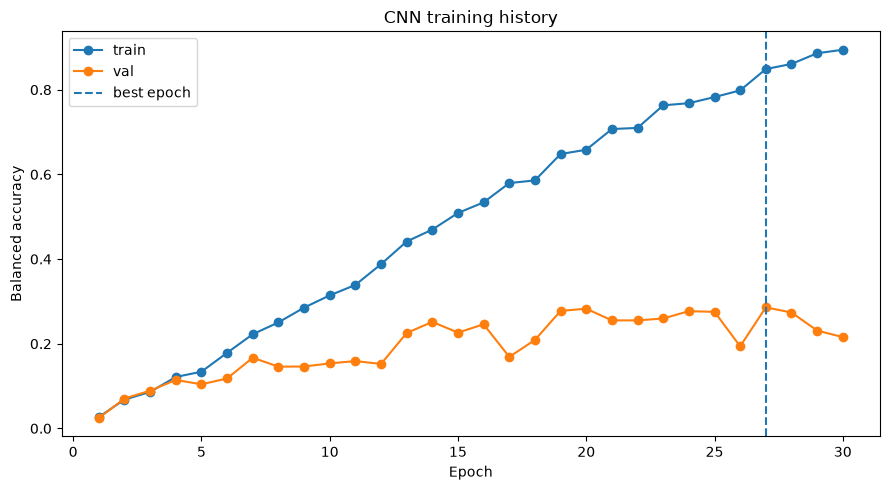

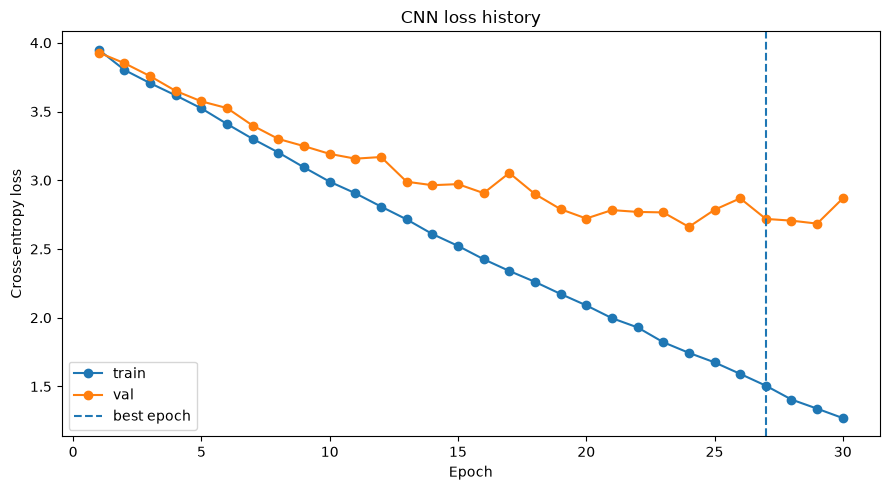

In [15]:
plt.figure(figsize=(9, 5))
for split_name in ("train", "val"):
    values = history.loc[history["split"] == split_name]
    plt.plot(values["epoch"], values["balanced_accuracy"], marker="o", label=split_name)
plt.axvline(best_epoch, linestyle="--", label="best epoch")
plt.xlabel("Epoch")
plt.ylabel("Balanced accuracy")
plt.title("CNN training history")
plt.legend()
plt.tight_layout()
if SAVE_FIGURES:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    plt.savefig(OUTPUT_DIR / "cnn_training_balanced_accuracy.png", dpi=180)
plt.show()

plt.figure(figsize=(9, 5))
for split_name in ("train", "val"):
    values = history.loc[history["split"] == split_name]
    plt.plot(values["epoch"], values["loss"], marker="o", label=split_name)
plt.axvline(best_epoch, linestyle="--", label="best epoch")
plt.xlabel("Epoch")
plt.ylabel("Cross-entropy loss")
plt.title("CNN loss history")
plt.legend()
plt.tight_layout()
if SAVE_FIGURES:
    plt.savefig(OUTPUT_DIR / "cnn_training_loss.png", dpi=180)
plt.show()


## 10. Extract 256-D embeddings

保存两种表示：

- `h`：masked GAP 的原始 256-D feature，供 classifier / linear probe 使用；
- `z = h / ||h||₂`：单位球上的 representation，供 cosine retrieval 和 geometry 使用。


In [16]:
@torch.inference_mode()
def extract_embeddings(
    model: nn.Module,
    loader: DataLoader[dict[str, object]],
    *,
    device: torch.device,
) -> dict[str, object]:
    model.eval()
    h_parts: list[np.ndarray] = []
    y_parts: list[np.ndarray] = []
    pred_parts: list[np.ndarray] = []
    logit_parts: list[np.ndarray] = []
    sample_ids: list[str] = []

    for batch in loader:
        x = batch["x"].to(device=device, dtype=torch.float32, non_blocking=True)
        valid_mask = batch["valid_mask"].to(device=device, dtype=torch.bool, non_blocking=True)
        labels = batch["label"].to(dtype=torch.long)
        logits, h = model(x, valid_mask=valid_mask)
        h_parts.append(h.cpu().numpy().astype(np.float32, copy=False))
        y_parts.append(labels.numpy().astype(np.int64, copy=False))
        pred_parts.append(logits.argmax(dim=1).cpu().numpy().astype(np.int64, copy=False))
        logit_parts.append(logits.cpu().numpy().astype(np.float32, copy=False))
        sample_ids.extend(str(value) for value in batch["sample_id"])

    h_all = np.concatenate(h_parts, axis=0)
    y_all = np.concatenate(y_parts, axis=0)
    pred_all = np.concatenate(pred_parts, axis=0)
    logits_all = np.concatenate(logit_parts, axis=0)
    norms = np.linalg.norm(h_all, axis=1, keepdims=True)
    if np.any(norms <= 0) or not np.isfinite(norms).all():
        raise FloatingPointError("Every embedding must have a finite positive L2 norm")
    z_all = h_all / norms
    if not np.allclose(np.linalg.norm(z_all, axis=1), 1.0, rtol=1e-5, atol=1e-6):
        raise AssertionError("L2-normalized embeddings must have norm 1")

    return {
        "h": h_all,
        "z": z_all.astype(np.float32, copy=False),
        "y": y_all,
        "cnn_pred": pred_all,
        "logits": logits_all,
        "sample_id": np.asarray(sample_ids, dtype=str),
    }


embedding_loaders = {
    "train": train_eval_loader,
    "val": val_loader,
    "test": test_loader,
}
embeddings = {
    split_name: extract_embeddings(model, loader, device=DEVICE)
    for split_name, loader in embedding_loaders.items()
}

manifest_by_id = sample_manifest.set_index("sample_id", drop=False)
embedding_manifest_parts: list[pd.DataFrame] = []
for split_name, bundle in embeddings.items():
    ids = bundle["sample_id"].tolist()
    metadata = manifest_by_id.loc[ids].copy().reset_index(drop=True)
    metadata["cnn_prediction_idx"] = bundle["cnn_pred"]
    metadata["cnn_prediction_label"] = [idx_to_class[int(index)] for index in bundle["cnn_pred"]]
    metadata["cnn_correct"] = bundle["cnn_pred"] == bundle["y"]
    if not np.array_equal(metadata["label_idx"].to_numpy(np.int64), bundle["y"]):
        raise AssertionError(f"Embedding order does not match manifest labels for split {split_name}")
    embedding_manifest_parts.append(metadata)
embedding_manifest = pd.concat(embedding_manifest_parts, ignore_index=True)

for split_name, bundle in embeddings.items():
    print(
        f"{split_name}: h={bundle['h'].shape}, z={bundle['z'].shape}, "
        f"samples={len(bundle['y'])}"
    )


train: h=(1372, 256), z=(1372, 256), samples=1372
val: h=(276, 256), z=(276, 256), samples=276
test: h=(276, 256), z=(276, 256), samples=276


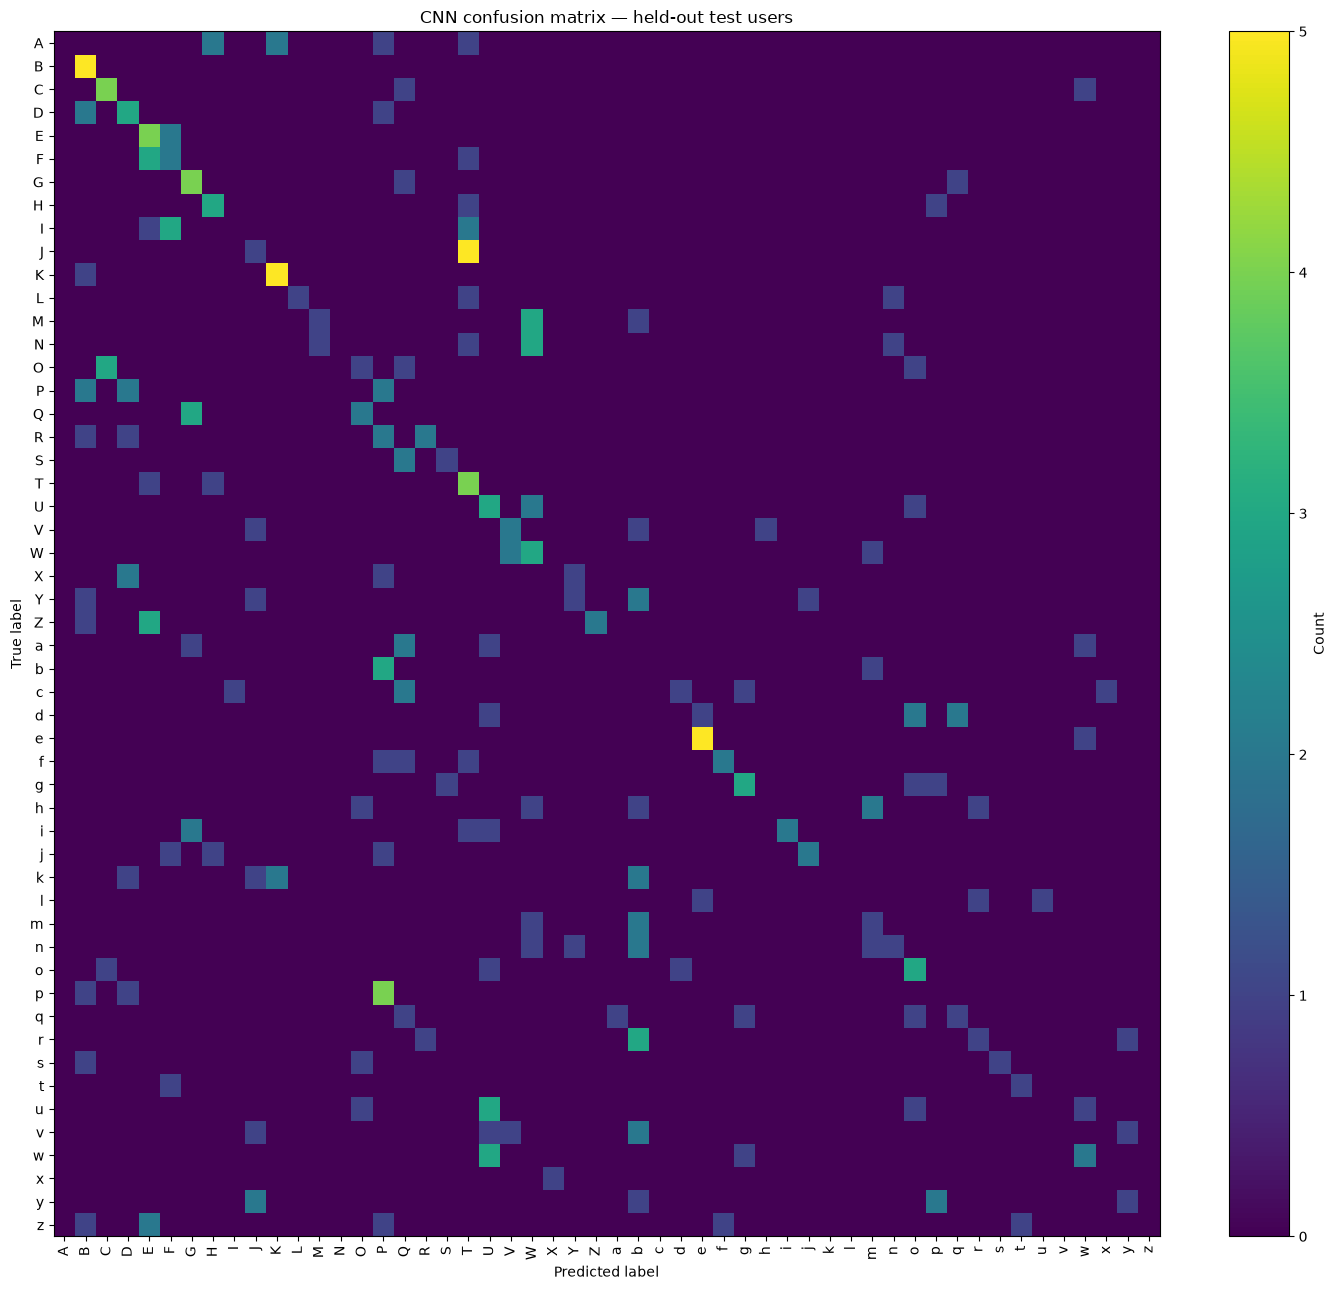

In [18]:
def confusion_matrix_numpy(y_true: np.ndarray, y_pred: np.ndarray, num_classes: int) -> np.ndarray:
    matrix = np.zeros((num_classes, num_classes), dtype=np.int64)
    np.add.at(matrix, (y_true.astype(np.int64), y_pred.astype(np.int64)), 1)
    return matrix


test_cm = confusion_matrix_numpy(
    embeddings["test"]["y"],
    embeddings["test"]["cnn_pred"],
    len(class_to_idx),
)

plt.figure(figsize=(max(8, len(all_labels) * 0.28), max(7, len(all_labels) * 0.25)))
plt.imshow(test_cm, aspect="auto")
plt.colorbar(label="Count")
plt.xticks(np.arange(len(all_labels)), all_labels, rotation=90)
plt.yticks(np.arange(len(all_labels)), all_labels)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("CNN confusion matrix — held-out test users")
plt.tight_layout()
if SAVE_FIGURES:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    plt.savefig(OUTPUT_DIR / "cnn_test_confusion_matrix.png", dpi=180)
plt.show()


## 11. Retrieval metrics: test query → train gallery

- **Same-label@K**：top-K neighbours 中同 label 的比例；同时报告 micro 和 macro-by-class。
- **kNN balanced accuracy**：K 在 validation query → train gallery 上选择，然后固定到 test。
- **mAP**：对 train gallery 的完整 cosine ranking 计算 AP；同 label 为 relevant。

这里不把 Same-label@K 称作 Recall@K，以避免分母定义歧义。


In [19]:
def macro_average_by_class(values: np.ndarray, labels: np.ndarray) -> float:
    per_class = [float(values[labels == class_index].mean()) for class_index in np.unique(labels)]
    return float(np.mean(per_class))


def cosine_topk(
    query_z: np.ndarray,
    gallery_z: np.ndarray,
    *,
    max_k: int,
    query_ids: np.ndarray | None = None,
    gallery_ids: np.ndarray | None = None,
    batch_size: int = 128,
) -> tuple[np.ndarray, np.ndarray]:
    query = np.asarray(query_z, dtype=np.float32)
    gallery = np.asarray(gallery_z, dtype=np.float32)
    if query.ndim != 2 or gallery.ndim != 2 or query.shape[1] != gallery.shape[1]:
        raise ValueError("query_z and gallery_z must be compatible 2-D matrices")
    if max_k <= 0 or max_k > len(gallery):
        raise ValueError(f"max_k must be in [1, {len(gallery)}], got {max_k}")

    all_indices: list[np.ndarray] = []
    all_scores: list[np.ndarray] = []
    for start in range(0, len(query), batch_size):
        stop = min(start + batch_size, len(query))
        scores = query[start:stop] @ gallery.T
        if query_ids is not None and gallery_ids is not None:
            duplicate = query_ids[start:stop, None] == gallery_ids[None, :]
            scores = scores.copy()
            scores[duplicate] = -np.inf
        candidate = np.argpartition(-scores, kth=max_k - 1, axis=1)[:, :max_k]
        candidate_scores = np.take_along_axis(scores, candidate, axis=1)
        order = np.argsort(-candidate_scores, axis=1, kind="stable")
        indices = np.take_along_axis(candidate, order, axis=1)
        sorted_scores = np.take_along_axis(candidate_scores, order, axis=1)
        all_indices.append(indices.astype(np.int64, copy=False))
        all_scores.append(sorted_scores.astype(np.float32, copy=False))
    return np.concatenate(all_indices), np.concatenate(all_scores)


def knn_predict_from_topk(
    neighbour_indices: np.ndarray,
    neighbour_scores: np.ndarray,
    gallery_y: np.ndarray,
    *,
    k: int,
) -> np.ndarray:
    predictions = np.empty(len(neighbour_indices), dtype=np.int64)
    for query_index in range(len(neighbour_indices)):
        labels = gallery_y[neighbour_indices[query_index, :k]]
        scores = neighbour_scores[query_index, :k]
        unique, counts = np.unique(labels, return_counts=True)
        max_count = counts.max()
        candidates = unique[counts == max_count]
        if len(candidates) == 1:
            predictions[query_index] = int(candidates[0])
            continue
        score_sums = {
            int(label): float(scores[labels == label].sum())
            for label in candidates
        }
        best_score = max(score_sums.values())
        predictions[query_index] = min(
            label for label, value in score_sums.items() if value == best_score
        )
    return predictions


def same_label_at_k(
    neighbour_indices: np.ndarray,
    *,
    query_y: np.ndarray,
    gallery_y: np.ndarray,
    k: int,
) -> tuple[float, float, np.ndarray]:
    relevant = gallery_y[neighbour_indices[:, :k]] == query_y[:, None]
    per_query = relevant.mean(axis=1, dtype=np.float64)
    return float(per_query.mean()), macro_average_by_class(per_query, query_y), per_query


def retrieval_map(
    query_z: np.ndarray,
    gallery_z: np.ndarray,
    *,
    query_y: np.ndarray,
    gallery_y: np.ndarray,
    query_ids: np.ndarray | None = None,
    gallery_ids: np.ndarray | None = None,
    batch_size: int = 128,
) -> tuple[float, float, np.ndarray]:
    aps = np.empty(len(query_z), dtype=np.float64)
    ranks = np.arange(1, len(gallery_z) + 1, dtype=np.float64)

    for start in range(0, len(query_z), batch_size):
        stop = min(start + batch_size, len(query_z))
        scores = np.asarray(query_z[start:stop], dtype=np.float32) @ np.asarray(
            gallery_z, dtype=np.float32
        ).T
        if query_ids is not None and gallery_ids is not None:
            duplicate = query_ids[start:stop, None] == gallery_ids[None, :]
            scores = scores.copy()
            scores[duplicate] = -np.inf
        ordering = np.argsort(-scores, axis=1, kind="stable")

        for local_index, global_index in enumerate(range(start, stop)):
            relevant_count = int(np.count_nonzero(gallery_y == query_y[global_index]))
            if relevant_count <= 0:
                raise ValueError(
                    f"Query {global_index} has no same-label item in the train gallery"
                )
            relevance = gallery_y[ordering[local_index]] == query_y[global_index]
            cumulative = np.cumsum(relevance, dtype=np.float64)
            precision = cumulative / ranks
            aps[global_index] = float((precision * relevance).sum() / relevant_count)

    return float(aps.mean()), macro_average_by_class(aps, query_y), aps


def select_knn_k(
    *,
    val_z: np.ndarray,
    val_y: np.ndarray,
    train_z: np.ndarray,
    train_y: np.ndarray,
    candidates: Sequence[int],
) -> tuple[int, pd.DataFrame]:
    candidates = sorted(set(int(value) for value in candidates))
    max_k = max(candidates)
    indices, scores = cosine_topk(
        val_z,
        train_z,
        max_k=max_k,
        batch_size=SIMILARITY_QUERY_BATCH_SIZE,
    )
    rows: list[dict[str, float | int]] = []
    for k in candidates:
        prediction = knn_predict_from_topk(indices, scores, train_y, k=k)
        metrics = _classification_metrics(val_y.tolist(), prediction.tolist())
        rows.append({"k": k, **metrics})
    table = pd.DataFrame(rows).sort_values("k").reset_index(drop=True)
    best_row = table.sort_values(
        ["balanced_accuracy", "k"], ascending=[False, True], kind="stable"
    ).iloc[0]
    return int(best_row["k"]), table


In [20]:
train_bundle = embeddings["train"]
val_bundle = embeddings["val"]
test_bundle = embeddings["test"]

max_requested_k = max(*K_VALUES, *KNN_K_CANDIDATES)
if max_requested_k > len(train_bundle["y"]):
    raise ValueError(
        f"Largest requested K={max_requested_k} exceeds train gallery size={len(train_bundle['y'])}"
    )

selected_knn_k, validation_knn_table = select_knn_k(
    val_z=val_bundle["z"],
    val_y=val_bundle["y"],
    train_z=train_bundle["z"],
    train_y=train_bundle["y"],
    candidates=KNN_K_CANDIDATES,
)
print(f"Selected kNN K from validation: {selected_knn_k}")
display(validation_knn_table)

test_topk_indices, test_topk_scores = cosine_topk(
    test_bundle["z"],
    train_bundle["z"],
    max_k=max(max(K_VALUES), selected_knn_k),
    batch_size=SIMILARITY_QUERY_BATCH_SIZE,
)
test_knn_prediction = knn_predict_from_topk(
    test_topk_indices,
    test_topk_scores,
    train_bundle["y"],
    k=selected_knn_k,
)
test_knn_metrics = _classification_metrics(
    test_bundle["y"].tolist(), test_knn_prediction.tolist()
)

same_label_rows: list[dict[str, float | int]] = []
for k in K_VALUES:
    micro_value, macro_value, _ = same_label_at_k(
        test_topk_indices,
        query_y=test_bundle["y"],
        gallery_y=train_bundle["y"],
        k=k,
    )
    same_label_rows.append(
        {"k": k, "same_label_micro": micro_value, "same_label_macro": macro_value}
    )
same_label_table = pd.DataFrame(same_label_rows)

retrieval_map_micro, retrieval_map_macro, test_average_precision = retrieval_map(
    test_bundle["z"],
    train_bundle["z"],
    query_y=test_bundle["y"],
    gallery_y=train_bundle["y"],
    query_ids=test_bundle["sample_id"],
    gallery_ids=train_bundle["sample_id"],
    batch_size=SIMILARITY_QUERY_BATCH_SIZE,
)

retrieval_summary = pd.DataFrame(
    [
        {
            "selected_knn_k": selected_knn_k,
            "knn_balanced_accuracy": test_knn_metrics["balanced_accuracy"],
            "knn_accuracy": test_knn_metrics["accuracy"],
            "knn_macro_f1": test_knn_metrics["macro_f1"],
            "retrieval_mAP_micro": retrieval_map_micro,
            "retrieval_mAP_macro": retrieval_map_macro,
        }
    ]
)

display(retrieval_summary)
display(same_label_table)


Selected kNN K from validation: 10


,k,accuracy,balanced_accuracy,macro_f1,weighted_f1
0,1,0.271739,0.272436,0.261416,0.257844
1,3,0.260870,0.262179,0.263016,0.259351
2,5,0.260870,0.260897,0.251182,0.247966
3,7,0.282609,0.284936,0.269027,0.263740
4,10,0.304348,0.300321,0.285173,0.284750
5,15,0.282609,0.276603,0.258170,0.259587
6,20,0.289855,0.284295,0.269405,0.269168


,selected_knn_k,knn_balanced_accuracy,knn_accuracy,knn_macro_f1,retrieval_mAP_micro,retrieval_mAP_macro
0,10,0.278205,0.278986,0.247726,0.187402,0.186688


,k,same_label_micro,same_label_macro
0,1,0.253623,0.249679
1,3,0.256039,0.256090
2,5,0.234783,0.233590
3,10,0.219203,0.217532
4,20,0.198913,0.198269
5,50,0.157319,0.156205


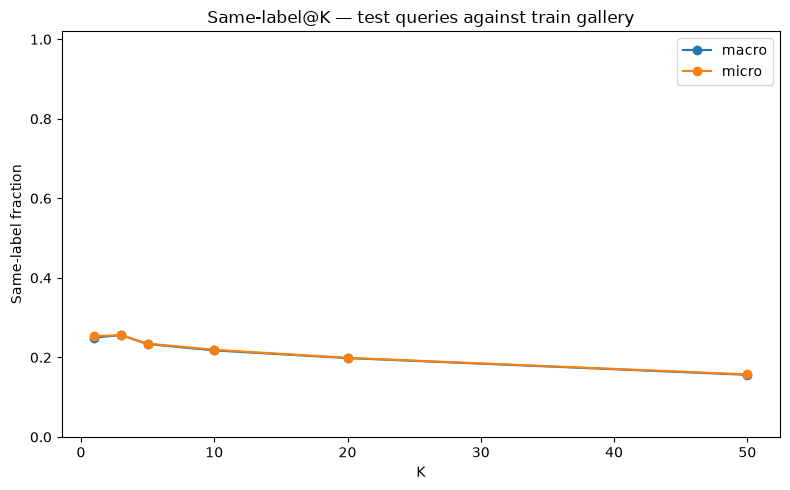

In [21]:
plt.figure(figsize=(8, 5))
plt.plot(
    same_label_table["k"],
    same_label_table["same_label_macro"],
    marker="o",
    label="macro",
)
plt.plot(
    same_label_table["k"],
    same_label_table["same_label_micro"],
    marker="o",
    label="micro",
)
plt.xlabel("K")
plt.ylabel("Same-label fraction")
plt.ylim(0.0, 1.02)
plt.title("Same-label@K — test queries against train gallery")
plt.legend()
plt.tight_layout()
if SAVE_FIGURES:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    plt.savefig(OUTPUT_DIR / "same_label_at_k_curve.png", dpi=180)
plt.show()


## 12. Test-only geometry and train-prototype evaluation

- `Dintra`：每个 class 内所有 unordered pair 的平均 cosine distance，再 macro-average；利用向量和公式精确计算，不建立完整 pair matrix。
- `Dinter`：L2-normalized class centroids 之间的平均 cosine distance。
- `Dinter / Dintra`：separation ratio，越高越好。
- Prototype accuracy：train class centroids → test samples。


In [27]:
def class_centroids(
    z: np.ndarray,
    y: np.ndarray,
) -> tuple[np.ndarray, np.ndarray]:
    classes = np.unique(y)
    centroids: list[np.ndarray] = []
    for class_index in classes:
        centroid = z[y == class_index].mean(axis=0, dtype=np.float64)
        norm = float(np.linalg.norm(centroid))
        if not math.isfinite(norm) or norm <= 0:
            raise FloatingPointError(f"Invalid centroid for class {class_index}")
        centroids.append((centroid / norm).astype(np.float32))
    return classes.astype(np.int64), np.stack(centroids)


def macro_intra_cosine_distance(
    z: np.ndarray,
    y: np.ndarray,
) -> tuple[float, pd.DataFrame]:
    rows: list[dict[str, float | int | str]] = []
    skipped: list[int] = []

    for class_index in np.unique(y):
        class_z = np.asarray(
            z[y == class_index],
            dtype=np.float64,
        )
        n = len(class_z)

        # D_intra requires at least one pair of samples.
        # Singleton classes cannot define an intra-class distance.
        if n < 2:
            skipped.append(int(class_index))
            continue

        vector_sum = class_z.sum(axis=0)

        # z is L2-normalized.
        # Mean cosine similarity over unordered within-class pairs.
        mean_pair_cosine = (
            float(vector_sum @ vector_sum) - n
        ) / (n * (n - 1))

        distance = 1.0 - mean_pair_cosine

        rows.append(
            {
                "label_idx": int(class_index),
                "label": idx_to_class[int(class_index)],
                "test_samples": int(n),
                "intra_cosine_distance": float(distance),
            }
        )

    if not rows:
        raise ValueError(
            "No test class has at least two samples; "
            "D_intra cannot be computed."
        )

    table = (
        pd.DataFrame(rows)
        .sort_values("label_idx")
        .reset_index(drop=True)
    )

    d_intra = float(
        table["intra_cosine_distance"].mean()
    )

    print(
        f"D_intra computed from {len(table)} eligible classes; "
        f"{len(skipped)} singleton class(es) skipped."
    )

    if skipped:
        skipped_labels = [
            idx_to_class[int(class_index)]
            for class_index in skipped
        ]

        print("Skipped singleton class indices:", skipped)
        print("Skipped singleton labels:", skipped_labels)

    return d_intra, table


def centroid_inter_cosine_distance(z: np.ndarray, y: np.ndarray) -> float:
    _, centroids = class_centroids(z, y)
    if len(centroids) < 2:
        raise ValueError("Dinter requires at least two classes")
    distances = 1.0 - centroids @ centroids.T
    upper = distances[np.triu_indices(len(centroids), k=1)]
    return float(upper.mean())


def prototype_classification(
    *,
    train_z: np.ndarray,
    train_y: np.ndarray,
    test_z: np.ndarray,
    test_y: np.ndarray,
) -> tuple[dict[str, float], np.ndarray]:
    classes, centroids = class_centroids(train_z, train_y)
    scores = np.asarray(test_z, dtype=np.float32) @ centroids.T
    predictions = classes[scores.argmax(axis=1)]
    return _classification_metrics(test_y.tolist(), predictions.tolist()), predictions


d_intra, intra_by_class = macro_intra_cosine_distance(test_bundle["z"], test_bundle["y"])
d_inter = centroid_inter_cosine_distance(test_bundle["z"], test_bundle["y"])
separation_ratio = d_inter / (d_intra + 1e-12)
prototype_metrics, prototype_prediction = prototype_classification(
    train_z=train_bundle["z"],
    train_y=train_bundle["y"],
    test_z=test_bundle["z"],
    test_y=test_bundle["y"],
)

geometry_summary = pd.DataFrame(
    [
        {
            "D_intra_macro": d_intra,
            "D_inter_centroids": d_inter,
            "D_inter_over_D_intra": separation_ratio,
            "prototype_balanced_accuracy": prototype_metrics["balanced_accuracy"],
            "prototype_accuracy": prototype_metrics["accuracy"],
            "prototype_macro_f1": prototype_metrics["macro_f1"],
        }
    ]
)
display(geometry_summary)
display(intra_by_class)


D_intra computed from 51 eligible classes; 1 singleton class(es) skipped.
Skipped singleton class indices: [49]
Skipped singleton labels: ['x']


,D_intra_macro,D_inter_centroids,D_inter_over_D_intra,prototype_balanced_accuracy,prototype_accuracy,prototype_macro_f1
0,0.083973,0.104301,1.242068,0.295192,0.282609,0.250124


,label_idx,label,test_samples,intra_cosine_distance
0,0,A,6,0.072674
1,1,B,5,0.044005
2,2,C,6,0.089340
3,3,D,6,0.041461
4,4,E,6,0.047493
5,5,F,6,0.049081
6,6,G,6,0.064374
7,7,H,5,0.066618
8,8,I,6,0.075009
9,9,J,6,0.102459


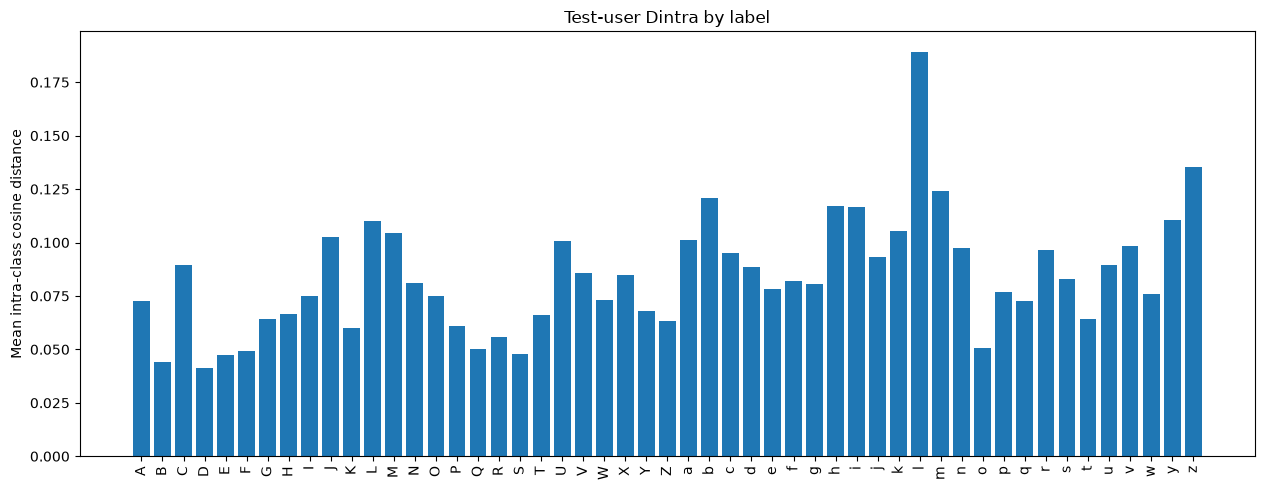

In [28]:
plt.figure(figsize=(max(10, len(intra_by_class) * 0.25), 5))
plt.bar(np.arange(len(intra_by_class)), intra_by_class["intra_cosine_distance"])
plt.xticks(np.arange(len(intra_by_class)), intra_by_class["label"], rotation=90)
plt.ylabel("Mean intra-class cosine distance")
plt.title("Test-user Dintra by label")
plt.tight_layout()
if SAVE_FIGURES:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    plt.savefig(OUTPUT_DIR / "test_intra_distance_by_label.png", dpi=180)
plt.show()


## 13. Frozen-encoder linear probe

冻结 CNN，只在 train `h` 上训练一个线性层；feature standardization 也只使用 train `h`。Best probe state 由 validation balanced accuracy 决定，最后只在 test 上评估。


In [46]:
def standardize_feature_splits(
    train_x: np.ndarray,
    val_x: np.ndarray,
    test_x: np.ndarray,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    mean = train_x.mean(axis=0, dtype=np.float64)
    std = train_x.std(axis=0, dtype=np.float64)
    std = np.where(std < 1e-8, 1.0, std)
    transform = lambda values: ((values - mean) / std).astype(np.float32)
    return transform(train_x), transform(val_x), transform(test_x), mean, std


@torch.inference_mode()
def evaluate_linear_probe(
    probe: nn.Module,
    features: np.ndarray,
    labels: np.ndarray,
    *,
    device: torch.device,
) -> dict[str, float]:
    probe.eval()
    logits_parts: list[np.ndarray] = []
    for start in range(0, len(features), LINEAR_PROBE_BATCH_SIZE):
        stop = min(start + LINEAR_PROBE_BATCH_SIZE, len(features))
        batch = torch.from_numpy(features[start:stop]).to(device=device, dtype=torch.float32)
        logits_parts.append(probe(batch).cpu().numpy())
    logits = np.concatenate(logits_parts)
    predictions = logits.argmax(axis=1).astype(np.int64)
    return _classification_metrics(labels.tolist(), predictions.tolist())


def train_linear_probe(
    train_x: np.ndarray,
    train_y: np.ndarray,
    val_x: np.ndarray,
    val_y: np.ndarray,
    *,
    num_classes: int,
    device: torch.device,
) -> tuple[nn.Module, pd.DataFrame, int, float]:
    _set_random_seed(RANDOM_SEED + 1)
    probe = nn.Linear(train_x.shape[1], num_classes).to(device)
    optimizer = torch.optim.Adam(
        probe.parameters(),
        lr=LINEAR_PROBE_LEARNING_RATE,
        weight_decay=LINEAR_PROBE_WEIGHT_DECAY,
    )
    criterion = nn.CrossEntropyLoss()
    dataset = TensorDataset(
        torch.from_numpy(train_x),
        torch.from_numpy(train_y.astype(np.int64, copy=False)),
    )
    loader = DataLoader(
        dataset,
        batch_size=min(LINEAR_PROBE_BATCH_SIZE, len(dataset)),
        shuffle=True,
        generator=torch.Generator().manual_seed(RANDOM_SEED + 1),
        num_workers=0,
    )

    best_state: dict[str, torch.Tensor] | None = None
    best_epoch = -1
    best_val = -math.inf
    no_improvement = 0
    rows: list[dict[str, float | int]] = []

    for epoch in range(1, LINEAR_PROBE_EPOCHS + 1):
        probe.train()
        train_loss_sum = 0.0
        train_count = 0
        for x_batch, y_batch in loader:
            x_batch = x_batch.to(device=device, dtype=torch.float32)
            y_batch = y_batch.to(device=device, dtype=torch.long)
            optimizer.zero_grad(set_to_none=True)
            logits = probe(x_batch)
            loss = criterion(logits, y_batch)
            loss.backward()
            optimizer.step()
            train_loss_sum += float(loss.detach()) * len(y_batch)
            train_count += len(y_batch)

        val_metrics = evaluate_linear_probe(probe, val_x, val_y, device=device)
        rows.append(
            {
                "epoch": epoch,
                "train_loss": train_loss_sum / train_count,
                "val_balanced_accuracy": val_metrics["balanced_accuracy"],
                "val_accuracy": val_metrics["accuracy"],
            }
        )
        current = float(val_metrics["balanced_accuracy"])
        if current > best_val + 1e-12:
            best_val = current
            best_epoch = epoch
            best_state = copy.deepcopy(probe.state_dict())
            no_improvement = 0
        else:
            no_improvement += 1

        if epoch == 1 or epoch % 20 == 0:
            print(
                f"Linear probe epoch {epoch:03d} | "
                f"loss={train_loss_sum / train_count:.5f}, val BA={current:.5f}"
            )
        if no_improvement >= LINEAR_PROBE_PATIENCE:
            break

    if best_state is None:
        raise RuntimeError("Linear probe did not produce a best state")
    probe.load_state_dict(best_state)
    return probe, pd.DataFrame(rows), best_epoch, best_val


probe_train_x, probe_val_x, probe_test_x, probe_mean, probe_std = standardize_feature_splits(
    train_bundle["h"], val_bundle["h"], test_bundle["h"]
)
linear_probe, linear_probe_history, linear_probe_best_epoch, linear_probe_best_val = train_linear_probe(
    probe_train_x,
    train_bundle["y"],
    probe_val_x,
    val_bundle["y"],
    num_classes=len(class_to_idx),
    device=DEVICE,
)
linear_probe_test_metrics = evaluate_linear_probe(
    linear_probe,
    probe_test_x,
    test_bundle["y"],
    device=DEVICE,
)

linear_probe_summary = pd.DataFrame(
    [
        {
            "best_epoch": linear_probe_best_epoch,
            "best_val_balanced_accuracy": linear_probe_best_val,
            "test_balanced_accuracy": linear_probe_test_metrics["balanced_accuracy"],
            "test_accuracy": linear_probe_test_metrics["accuracy"],
            "test_macro_f1": linear_probe_test_metrics["macro_f1"],
        }
    ]
)
display(linear_probe_summary)


Linear probe epoch 001 | loss=3.21838, val BA=0.20865
Linear probe epoch 020 | loss=0.12933, val BA=0.32564
Linear probe epoch 040 | loss=0.06220, val BA=0.32083


,best_epoch,best_val_balanced_accuracy,test_balanced_accuracy,test_accuracy,test_macro_f1
0,11,0.340385,0.225,0.217391,0.204466


## 14. Unsupervised test-user diagnostics

在 `z_test` 上运行 KMeans（`K = #classes`），不向聚类算法提供 labels；然后计算：

- NMI（arithmetic normalization）；
- ARI；
- supervised-label silhouette（cosine distance，class-balanced subsample）。

这些指标是 diagnostics。Coarse label 可能天然 multi-modal，因此不作为唯一主结论。


In [50]:
def squared_euclidean_matrix(x: np.ndarray, centers: np.ndarray) -> np.ndarray:
    x_sq = np.square(x).sum(axis=1, keepdims=True)
    c_sq = np.square(centers).sum(axis=1, keepdims=True).T
    return np.maximum(x_sq + c_sq - 2.0 * x @ centers.T, 0.0)


def kmeans_plus_plus_init(
    x: np.ndarray,
    k: int,
    *,
    rng: np.random.Generator,
) -> np.ndarray:
    if k <= 0 or k > len(x):
        raise ValueError(f"k must be in [1, {len(x)}]")
    centers = np.empty((k, x.shape[1]), dtype=np.float32)
    first = int(rng.integers(len(x)))
    centers[0] = x[first]
    closest = squared_euclidean_matrix(x, centers[:1])[:, 0]

    for center_index in range(1, k):
        total = float(closest.sum())
        if not math.isfinite(total) or total <= 0:
            chosen = int(rng.integers(len(x)))
        else:
            chosen = int(rng.choice(len(x), p=closest / total))
        centers[center_index] = x[chosen]
        new_distance = squared_euclidean_matrix(x, centers[center_index : center_index + 1])[:, 0]
        closest = np.minimum(closest, new_distance)
    return centers


def run_kmeans_once(
    x: np.ndarray,
    *,
    k: int,
    rng: np.random.Generator,
    max_iter: int,
) -> tuple[np.ndarray, np.ndarray, float]:
    centers = kmeans_plus_plus_init(x, k, rng=rng)
    previous_assignment: np.ndarray | None = None

    for _ in range(max_iter):
        distances = squared_euclidean_matrix(x, centers)
        assignment = distances.argmin(axis=1).astype(np.int64)
        if previous_assignment is not None and np.array_equal(assignment, previous_assignment):
            break
        previous_assignment = assignment.copy()

        nearest_distance = distances[np.arange(len(x)), assignment]
        new_centers = np.empty_like(centers)
        for cluster_index in range(k):
            members = x[assignment == cluster_index]
            if len(members) == 0:
                replacement = int(np.argmax(nearest_distance))
                new_centers[cluster_index] = x[replacement]
                nearest_distance[replacement] = -np.inf
            else:
                new_centers[cluster_index] = members.mean(axis=0)
        centers = new_centers

    final_distances = squared_euclidean_matrix(x, centers)
    assignment = final_distances.argmin(axis=1).astype(np.int64)
    inertia = float(final_distances[np.arange(len(x)), assignment].sum())
    return assignment, centers, inertia


def kmeans_best_of_n(
    x: np.ndarray,
    *,
    k: int,
    n_init: int,
    max_iter: int,
    seed: int,
) -> tuple[np.ndarray, np.ndarray, float]:
    best_assignment: np.ndarray | None = None
    best_centers: np.ndarray | None = None
    best_inertia = math.inf
    for init_index in range(n_init):
        rng = np.random.default_rng(seed + init_index)
        assignment, centers, inertia = run_kmeans_once(
            np.asarray(x, dtype=np.float32),
            k=k,
            rng=rng,
            max_iter=max_iter,
        )
        if inertia < best_inertia:
            best_assignment = assignment
            best_centers = centers
            best_inertia = inertia
    if best_assignment is None or best_centers is None:
        raise RuntimeError("KMeans failed to produce a solution")
    return best_assignment, best_centers, best_inertia


def contingency_matrix_numpy(y_true: np.ndarray, y_pred: np.ndarray) -> np.ndarray:
    true_values, true_inverse = np.unique(y_true, return_inverse=True)
    pred_values, pred_inverse = np.unique(y_pred, return_inverse=True)
    matrix = np.zeros((len(true_values), len(pred_values)), dtype=np.int64)
    np.add.at(matrix, (true_inverse, pred_inverse), 1)
    return matrix


def normalized_mutual_information(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    contingency = contingency_matrix_numpy(y_true, y_pred).astype(np.float64)
    n = contingency.sum()
    row = contingency.sum(axis=1, keepdims=True)
    col = contingency.sum(axis=0, keepdims=True)
    nonzero = contingency > 0
    expected = row @ col / n
    mutual_information = float(
        np.sum((contingency[nonzero] / n) * np.log(contingency[nonzero] / expected[nonzero]))
    )
    row_prob = row.ravel() / n
    col_prob = col.ravel() / n
    h_true = float(-np.sum(row_prob[row_prob > 0] * np.log(row_prob[row_prob > 0])))
    h_pred = float(-np.sum(col_prob[col_prob > 0] * np.log(col_prob[col_prob > 0])))
    denominator = h_true + h_pred
    return 1.0 if denominator == 0 else float(2.0 * mutual_information / denominator)


def comb2(values: np.ndarray | float) -> np.ndarray | float:
    return np.asarray(values) * (np.asarray(values) - 1.0) / 2.0


def adjusted_rand_index(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    contingency = contingency_matrix_numpy(y_true, y_pred).astype(np.float64)
    n = contingency.sum()
    if n < 2:
        return 1.0
    sum_comb = float(comb2(contingency).sum())
    row_comb = float(comb2(contingency.sum(axis=1)).sum())
    col_comb = float(comb2(contingency.sum(axis=0)).sum())
    total_comb = float(comb2(n))
    expected = row_comb * col_comb / total_comb
    maximum = 0.5 * (row_comb + col_comb)
    denominator = maximum - expected
    if denominator == 0:
        return 1.0 if sum_comb == maximum else 0.0
    return float((sum_comb - expected) / denominator)


def balanced_subsample_indices(
    labels: np.ndarray,
    *,
    max_samples: int,
    seed: int,
) -> np.ndarray:
    if len(labels) <= max_samples:
        return np.arange(len(labels), dtype=np.int64)
    classes = np.unique(labels)
    rng = np.random.default_rng(seed)
    quota = max(1, max_samples // len(classes))
    selected: list[int] = []
    remaining: list[int] = []
    for class_index in classes:
        indices = np.flatnonzero(labels == class_index)
        shuffled = rng.permutation(indices)
        selected.extend(shuffled[: min(quota, len(shuffled))].tolist())
        remaining.extend(shuffled[min(quota, len(shuffled)) :].tolist())
    slots = max_samples - len(selected)
    if slots > 0 and remaining:
        selected.extend(rng.choice(remaining, size=min(slots, len(remaining)), replace=False).tolist())
    return np.asarray(sorted(selected[:max_samples]), dtype=np.int64)


def cosine_silhouette(
    z: np.ndarray,
    y: np.ndarray,
    *,
    max_samples: int | None = None,
    seed: int = 12345,
):
    z = np.asarray(z, dtype=np.float64)
    y = np.asarray(y)

    if z.ndim != 2:
        raise ValueError(f"z must be 2-D, got {z.shape}")
    if y.ndim != 1 or len(y) != len(z):
        raise ValueError("y must be 1-D and aligned with z")

    rng = np.random.default_rng(seed)

    # ------------------------------------------------------------
    # Optional sampling
    # ------------------------------------------------------------
    if max_samples is not None and len(z) > max_samples:
        indices = np.sort(
            rng.choice(
                len(z),
                size=max_samples,
                replace=False,
            )
        )
    else:
        indices = np.arange(len(z))

    sample_z = z[indices]
    sample_y = y[indices]

    # cosine distance because z is already L2-normalized
    similarity = sample_z @ sample_z.T
    distance = 1.0 - similarity

    # Numerical cleanup
    distance = np.clip(distance, 0.0, 2.0)
    np.fill_diagonal(distance, 0.0)

    classes, counts = np.unique(
        sample_y,
        return_counts=True,
    )

    class_counts = dict(zip(classes.tolist(), counts.tolist()))

    singleton_classes = {
        int(class_index)
        for class_index, count in class_counts.items()
        if count < 2
    }

    silhouette_values = []
    silhouette_indices = []
    silhouette_labels = []

    all_classes = np.unique(sample_y)

    for row_index, class_index in enumerate(sample_y):
        # Silhouette is undefined when this sample is the only
        # member of its own class.
        if class_counts[class_index] < 2:
            continue

        same = sample_y == class_index
        same[row_index] = False

        # a(i): mean distance to other samples of same class
        a = float(distance[row_index, same].mean())

        # b(i): smallest mean distance to any other class
        b = math.inf

        for other_class in all_classes:
            if other_class == class_index:
                continue

            other = sample_y == other_class

            if not other.any():
                continue

            mean_distance = float(
                distance[row_index, other].mean()
            )

            b = min(b, mean_distance)

        if not math.isfinite(b):
            raise ValueError(
                "Silhouette requires at least two represented classes"
            )

        denominator = max(a, b)

        if denominator <= 1e-12:
            s = 0.0
        else:
            s = (b - a) / denominator

        silhouette_values.append(float(s))
        silhouette_indices.append(int(indices[row_index]))
        silhouette_labels.append(int(class_index))

    if not silhouette_values:
        raise ValueError(
            "No eligible samples remain for silhouette evaluation"
        )

    silhouette_values = np.asarray(
        silhouette_values,
        dtype=np.float64,
    )
    silhouette_indices = np.asarray(
        silhouette_indices,
        dtype=np.int64,
    )
    silhouette_labels = np.asarray(
        silhouette_labels,
    )

    # Micro: every eligible sample gets equal weight
    silhouette_micro = float(
        silhouette_values.mean()
    )

    # Macro: every eligible class gets equal weight
    per_class = []

    for class_index in np.unique(silhouette_labels):
        class_values = silhouette_values[
            silhouette_labels == class_index
        ]

        per_class.append(
            float(class_values.mean())
        )

    silhouette_macro = float(
        np.mean(per_class)
    )

    print(
        f"Silhouette computed from "
        f"{len(silhouette_values)} eligible samples "
        f"across {len(per_class)} classes."
    )

    if singleton_classes:
        singleton_labels = [
            idx_to_class[int(class_index)]
            for class_index in sorted(singleton_classes)
        ]

        print(
            f"Skipped {len(singleton_classes)} "
            "singleton class(es) as silhouette queries."
        )
        print(
            "Skipped singleton class indices:",
            sorted(singleton_classes),
        )
        print(
            "Skipped singleton labels:",
            singleton_labels,
        )

    return (
        silhouette_micro,
        silhouette_macro,
        silhouette_values,
        silhouette_indices,
    )

num_test_classes = len(np.unique(test_bundle["y"]))
kmeans_assignment, kmeans_centers, kmeans_inertia = kmeans_best_of_n(
    test_bundle["z"],
    k=num_test_classes,
    n_init=KMEANS_N_INIT,
    max_iter=KMEANS_MAX_ITER,
    seed=RANDOM_SEED,
)
nmi_value = normalized_mutual_information(test_bundle["y"], kmeans_assignment)
ari_value = adjusted_rand_index(test_bundle["y"], kmeans_assignment)
silhouette_micro, silhouette_macro, silhouette_values, silhouette_indices = cosine_silhouette(
    test_bundle["z"],
    test_bundle["y"],
    max_samples=SILHOUETTE_MAX_SAMPLES,
    seed=RANDOM_SEED,
)

unsupervised_summary = pd.DataFrame(
    [
        {
            "kmeans_clusters": num_test_classes,
            "kmeans_inertia": kmeans_inertia,
            "NMI_arithmetic": nmi_value,
            "ARI": ari_value,
            "silhouette_micro": silhouette_micro,
            "silhouette_macro": silhouette_macro,
            "silhouette_samples": len(silhouette_indices),
        }
    ]
)
display(unsupervised_summary)


Silhouette computed from 275 eligible samples across 51 classes.
Skipped 1 singleton class(es) as silhouette queries.
Skipped singleton class indices: [49]
Skipped singleton labels: ['x']


,kmeans_clusters,kmeans_inertia,NMI_arithmetic,ARI,silhouette_micro,silhouette_macro,silhouette_samples
0,52,12.250782,0.64447,0.107914,-0.148408,-0.151087,275


## 15. PCA visualization (visual diagnostic only)

PCA 图只用于直观检查，不替代原始 256-D cosine metrics。


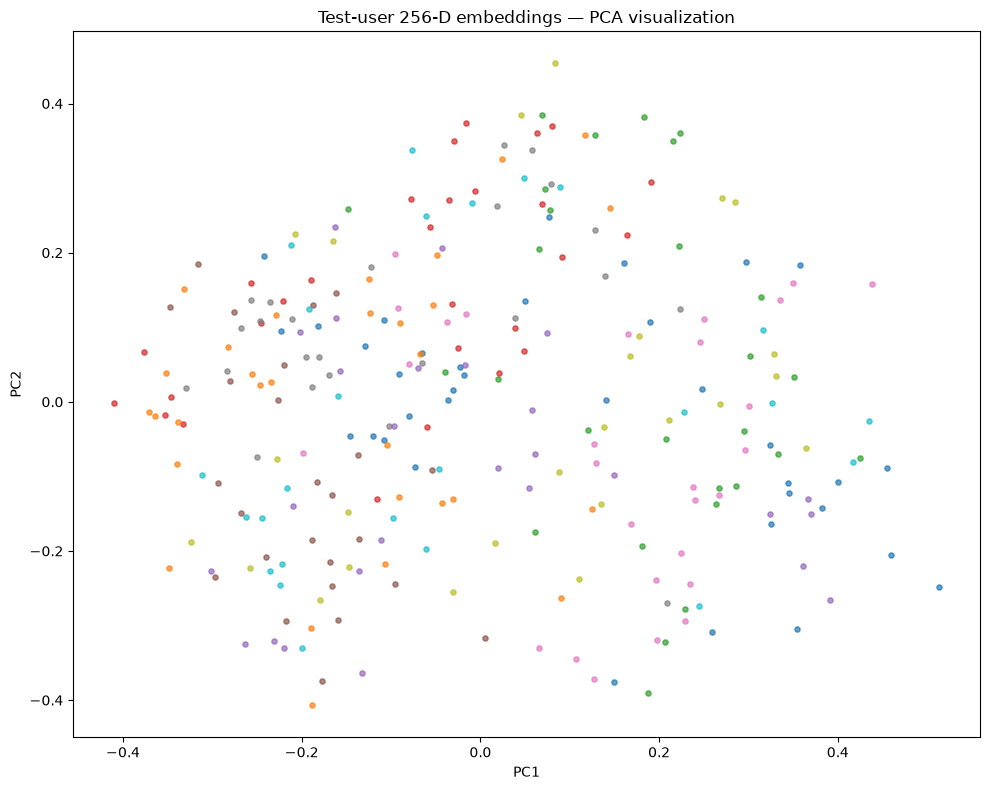

In [51]:
pca_indices = balanced_subsample_indices(
    test_bundle["y"],
    max_samples=PCA_MAX_SAMPLES,
    seed=RANDOM_SEED,
)
pca_z = np.asarray(test_bundle["z"][pca_indices], dtype=np.float64)
pca_y = np.asarray(test_bundle["y"][pca_indices], dtype=np.int64)
pca_centered = pca_z - pca_z.mean(axis=0, keepdims=True)
_, _, vt = np.linalg.svd(pca_centered, full_matrices=False)
pca_coordinates = pca_centered @ vt[:2].T

plt.figure(figsize=(10, 8))
for class_index in np.unique(pca_y):
    selected = pca_y == class_index
    plt.scatter(
        pca_coordinates[selected, 0],
        pca_coordinates[selected, 1],
        s=14,
        alpha=0.7,
        label=idx_to_class[int(class_index)],
    )
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Test-user 256-D embeddings — PCA visualization")
if len(np.unique(pca_y)) <= 20:
    plt.legend(bbox_to_anchor=(1.02, 1.0), loc="upper left")
plt.tight_layout()
if SAVE_FIGURES:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    plt.savefig(OUTPUT_DIR / "test_embedding_pca.png", dpi=180)
plt.show()


## 16. Final result tables

Primary metrics focus on classifier performance and label-aware metric geometry；complementary metrics describe global simplicity and unsupervised partition agreement。


In [52]:
primary_row: dict[str, float | int | str] = {
    "model": "AccelerationCNN",
    "best_epoch": best_epoch,
    "CNN_test_balanced_accuracy": split_metrics["test"]["balanced_accuracy"],
    "CNN_test_macro_f1": split_metrics["test"]["macro_f1"],
    "kNN_selected_K": selected_knn_k,
    "kNN_test_balanced_accuracy": test_knn_metrics["balanced_accuracy"],
    "retrieval_macro_mAP": retrieval_map_macro,
    "retrieval_micro_mAP": retrieval_map_micro,
    "D_intra_macro": d_intra,
    "D_inter_centroids": d_inter,
    "D_inter_over_D_intra": separation_ratio,
}
for row in same_label_rows:
    primary_row[f"SameLabel_macro_at_{int(row['k'])}"] = float(row["same_label_macro"])
    primary_row[f"SameLabel_micro_at_{int(row['k'])}"] = float(row["same_label_micro"])
primary_results = pd.DataFrame([primary_row])

complementary_results = pd.DataFrame(
    [
        {
            "model": "AccelerationCNN",
            "linear_probe_test_balanced_accuracy": linear_probe_test_metrics["balanced_accuracy"],
            "prototype_test_balanced_accuracy": prototype_metrics["balanced_accuracy"],
            "NMI_arithmetic": nmi_value,
            "ARI": ari_value,
            "silhouette_macro": silhouette_macro,
            "silhouette_micro": silhouette_micro,
        }
    ]
)

print("Primary results")
display(primary_results.T.rename(columns={0: "value"}))
print("Complementary diagnostics")
display(complementary_results.T.rename(columns={0: "value"}))


Primary results


,value
model,AccelerationCNN
best_epoch,27
CNN_test_balanced_accuracy,0.284295
CNN_test_macro_f1,0.259664
kNN_selected_K,10
kNN_test_balanced_accuracy,0.278205
retrieval_macro_mAP,0.186688
retrieval_micro_mAP,0.187402
D_intra_macro,0.083973
D_inter_centroids,0.104301


Complementary diagnostics


,value
model,AccelerationCNN
linear_probe_test_balanced_accuracy,0.225
prototype_test_balanced_accuracy,0.295192
NMI_arithmetic,0.64447
ARI,0.107914
silhouette_macro,-0.151087
silhouette_micro,-0.148408


## 17. Export checkpoint, embeddings, manifests, metrics, and provenance

输出默认写入：

```text
notebooks/artifacts/acceleration_cnn_representation/
```

包括：CNN checkpoint、每个 split 的 `h/z/y/sample_id`、segment manifest、history、结果 CSV 和 JSON provenance。


In [53]:
def json_safe(value: object) -> object:
    if isinstance(value, Path):
        return str(value)
    if isinstance(value, np.ndarray):
        return value.tolist()
    if isinstance(value, (np.integer,)):
        return int(value)
    if isinstance(value, (np.floating,)):
        return float(value)
    if isinstance(value, (np.bool_,)):
        return bool(value)
    if isinstance(value, torch.device):
        return str(value)
    if isinstance(value, Mapping):
        return {str(key): json_safe(item) for key, item in value.items()}
    if isinstance(value, (list, tuple, set)):
        return [json_safe(item) for item in value]
    return value


if SAVE_ARTIFACTS:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

    checkpoint = {
        "schema_version": 1,
        "artifact_type": "acceleration_cnn_representation_checkpoint",
        "model_state_dict": {key: value.detach().cpu() for key, value in model.state_dict().items()},
        "model_config": model.architecture_config(),
        "class_to_idx": class_to_idx,
        "acceleration_slice": [ACCELERATION_SLICE.start, ACCELERATION_SLICE.stop],
        "acceleration_channel_names": list(ACCELERATION_CHANNEL_NAMES),
        "normalization_mean": acceleration_mean.tolist(),
        "normalization_std": acceleration_std.tolist(),
        "train_users": TRAIN_USERS,
        "val_users": VAL_USERS,
        "test_users": TEST_USERS,
        "best_epoch": best_epoch,
        "best_val_balanced_accuracy": best_val_balanced_accuracy,
        "producer_metadata": asdict(producer_metadata),
    }
    torch.save(checkpoint, OUTPUT_DIR / "best_acceleration_cnn.pt")

    for split_name, bundle in embeddings.items():
        np.savez_compressed(
            OUTPUT_DIR / f"embeddings_{split_name}.npz",
            h=bundle["h"],
            z=bundle["z"],
            y=bundle["y"],
            cnn_pred=bundle["cnn_pred"],
            logits=bundle["logits"],
            sample_id=bundle["sample_id"],
        )

    sample_manifest.to_csv(OUTPUT_DIR / "source_sample_manifest.csv", index=False)
    embedding_manifest.to_csv(OUTPUT_DIR / "embedding_manifest.csv", index=False)
    history.to_csv(OUTPUT_DIR / "cnn_training_history.csv", index=False)
    linear_probe_history.to_csv(OUTPUT_DIR / "linear_probe_history.csv", index=False)
    validation_knn_table.to_csv(OUTPUT_DIR / "validation_knn_k_selection.csv", index=False)
    same_label_table.to_csv(OUTPUT_DIR / "test_same_label_at_k.csv", index=False)
    intra_by_class.to_csv(OUTPUT_DIR / "test_intra_distance_by_class.csv", index=False)
    primary_results.to_csv(OUTPUT_DIR / "primary_results.csv", index=False)
    complementary_results.to_csv(OUTPUT_DIR / "complementary_results.csv", index=False)

    experiment_provenance = {
        "repository_root": REPOSITORY_ROOT,
        "padded_root": PADDED_ROOT,
        "producer_metadata": asdict(producer_metadata),
        "package_count": len(packages),
        "segment_count": len(sample_manifest),
        "class_to_idx": class_to_idx,
        "train_users": TRAIN_USERS,
        "val_users": VAL_USERS,
        "test_users": TEST_USERS,
        "normalization": {
            "source": "train users and valid_mask=True samples only",
            "valid_time_points": normalization_valid_time_points,
            "mean": acceleration_mean,
            "std": acceleration_std,
        },
        "training": {
            "random_seed": RANDOM_SEED,
            "batch_size": BATCH_SIZE,
            "num_epochs_configured": NUM_EPOCHS,
            "learning_rate": LEARNING_RATE,
            "weight_decay": WEIGHT_DECAY,
            "best_epoch": best_epoch,
            "best_val_balanced_accuracy": best_val_balanced_accuracy,
            "device": DEVICE,
        },
        "model": model.architecture_config(),
        "retrieval_protocol": {
            "query": "test users",
            "gallery": "train users",
            "knn_k_selected_on": "validation users against train gallery",
            "selected_knn_k": selected_knn_k,
            "same_label_k_values": K_VALUES,
        },
        "primary_results": primary_results.iloc[0].to_dict(),
        "complementary_results": complementary_results.iloc[0].to_dict(),
    }
    (OUTPUT_DIR / "experiment_provenance.json").write_text(
        json.dumps(json_safe(experiment_provenance), ensure_ascii=False, indent=2) + "\n",
        encoding="utf-8",
    )

    print(f"Artifacts written to: {OUTPUT_DIR}")
    display(pd.DataFrame({"artifact": sorted(path.name for path in OUTPUT_DIR.iterdir())}))
else:
    print("SAVE_ARTIFACTS=False; no files were written.")


Artifacts written to: /home/ted/project/writingring-viz/notebooks/artifacts/acceleration_cnn_representation


,artifact
0,best_acceleration_cnn.pt
1,cnn_test_confusion_matrix.png
2,cnn_training_balanced_accuracy.png
3,cnn_training_history.csv
4,cnn_training_loss.png
5,complementary_results.csv
6,embedding_manifest.csv
7,embeddings_test.npz
8,embeddings_train.npz
9,embeddings_val.npz


## Interpretation checklist

- `CNN test balanced accuracy` 高：unseen-user classification 良好。
- `kNN BA / macro-mAP / Same-label@K` 高：局部 metric geometry 和完整 ranking 良好。
- `Prototype BA` 明显低于 kNN：class 可能是 multi-modal，不必直接判定 encoder 差。
- `Dintra`、silhouette、NMI/ARI 只作为 diagnostics；coarse labels 可以天然包含多个 subclusters。
- 所有正式 test 数字均来自训练期间未见过的 users；normalization、checkpoint、K selection 和 linear-probe selection 均不使用 test 信息。
